<a href="https://colab.research.google.com/github/francji1/01ADS/blob/main/lectures/L03_decision_trees/01ADS_L03_Regression_Trees_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lecture 03: Regression on tabular data – workflow, validation, decision trees and ensembles

Lecture workbook covering the workflow for regression on structured (tabular) data, train/test splitting and cross-validation, decision trees, tree ensembles and gradient boosting libraries.

## Schedule for today's lecture
- Regression workflow for tabular data
  - Metrics, train / validation / test split
  - k-fold cross-validation and its variants
  - Baselines, data leakage, pipelines
  - Hyperparameter tuning and nested cross-validation
- Decision trees
  - From intuition to the CART algorithm
  - Regularisation, pruning, and stability checks
- Ensembles built on trees
  - Voting, Bagging, Random Forests, Extra Trees
  - Boosting: AdaBoost, Gradient Boosting, early stopping
  - Stacking
- Modern gradient boosting libraries: XGBoost, LightGBM, CatBoost
- Model interpretation: feature importance, permutation importance, SHAP
- Regression workflow with a reusable preprocessing pipeline and Optuna tuning

## References and further reading
- https://github.com/ageron/handson-ml3
- https://github.com/jakevdp/PythonDataScienceHandbook
- https://scikit-learn.org/stable/supervised_learning.html
- https://scikit-learn.org/stable/modules/cross_validation.html
- https://scikit-learn.org/stable/common_pitfalls.html
- https://xgboost.readthedocs.io/en/stable/
- https://lightgbm.readthedocs.io/
- https://catboost.ai/en/docs/
- https://christophm.github.io/interpretable-ml-book/
- https://shap.readthedocs.io/en/latest/


## Setup

In [1]:

try:
    import google.colab  # type: ignore
    RUNNING_IN_COLAB = True
    print('Running inside Google Colab.')
except ImportError:
    RUNNING_IN_COLAB = False
    print('Running in a local Jupyter environment.')


Running in a local Jupyter environment.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

from sklearn import tree
from sklearn.datasets import load_iris, make_blobs, make_moons, make_circles, fetch_california_housing
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyRegressor
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    train_test_split, KFold, GroupKFold, TimeSeriesSplit,
    cross_val_score, cross_validate, GridSearchCV, RandomizedSearchCV,
)
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score, accuracy_score,
)

RANDOM_STATE = 42

# 0. Regression workflow for tabular data

**Regression** = predicting a numeric target $y$ from features $x$ (house price, energy consumption, time to failure, ...). Whatever model we use – linear regression, a decision tree or a gradient-boosted ensemble – the **workflow** around it is the same, and it often matters more than the choice of the model itself:

1. **Define the problem and the metric.** What is predicted, for whom, which error is acceptable?
   - **RMSE** – same units as $y$, penalises large errors,
   - **MAE** – robust to outliers,
   - $R^2$ – share of explained variance, i.e. improvement over always predicting the mean,
   - **MAPE** – relative error, unusable when $y$ is close to 0.
2. **Split off a test set** and do not touch it until the very end.
3. **Explore the training data** (EDA): distributions, missing values, outliers, suspicious features.
4. **Build a baseline**: a constant model (`DummyRegressor`) and a simple linear model. Every fancier model has to beat them.
5. **Put all preprocessing into a `Pipeline`**: imputation, encoding, scaling and feature engineering are fitted on the training folds only.
6. **Select the model and tune hyperparameters with cross-validation** on the training set.
7. **Refit the selected pipeline on the whole training set** and evaluate it **once** on the test set.
8. **Interpret and communicate** (feature importance, SHAP, error analysis), then deploy and monitor.

This section shows steps 2, 4, 5, 6 and 7 on the California housing data.

## 0.1 Train / validation / test split

- **Training set** – fits the model parameters.
- **Validation set** – compares models and tunes hyperparameters.
- **Test set** – one final, unbiased estimate of the generalisation error. If you look at the test score repeatedly and adjust the model, the test set silently becomes a validation set and the estimate becomes optimistic.

Typical choices are 60/20/20 (train/validation/test) or 80/20 (train/test) with cross-validation inside the training part. Things to think about:
- `shuffle=True` (the default) is fine for i.i.d. rows; **never shuffle time series**, split them by time.
- `random_state` makes the split reproducible.
- `stratify=` keeps class proportions in classification; for a skewed regression target you can stratify on the binned target (e.g. `pd.qcut`).
- Rows that belong together (several records of one customer, patient or house) must stay in the same part, otherwise the model is evaluated on "almost seen" data. Use a group split (`GroupShuffleSplit`, `GroupKFold`).

In [3]:
housing = fetch_california_housing(as_frame=True)
X_house, y_house = housing.data, housing.target  # target: median house value in units of 100 000 USD
print(X_house.shape)
X_house.head()

(20640, 8)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [4]:
# Stratify on the binned target, so that train and test have the same distribution of y
y_bins = pd.qcut(y_house, q=10, labels=False, duplicates="drop")
X_tr, X_te, y_tr, y_te = train_test_split(
    X_house, y_house, test_size=0.2, random_state=RANDOM_STATE, stratify=y_bins
)
print(f"train: {X_tr.shape}, test: {X_te.shape}")
print(f"mean of y  train: {y_tr.mean():.3f}  test: {y_te.mean():.3f}")

train: (16512, 8), test: (4128, 8)
mean of y  train: 2.070  test: 2.065


## 0.2 Cross-validation (k-fold)

A single validation split wastes data, and its score depends on the luck of the split. **k-fold cross-validation** splits the training set into $k$ folds. Each fold serves once as the validation set, while the model is trained on the remaining $k-1$ folds:

$$\mathrm{CV}_k = \frac{1}{k}\sum_{j=1}^{k} \mathrm{Err}\big(\hat f^{(-j)},\ \text{fold}_j\big),$$

where $\hat f^{(-j)}$ is the model trained without fold $j$.

- $k=5$ or $k=10$ are the usual defaults (trade-off between bias, variance and compute). $k=n$ is leave-one-out (LOOCV).
- Report the **mean and the standard deviation** across folds. Differences smaller than the standard deviation are usually noise.
- `RepeatedKFold` repeats k-fold with different shuffles and gives a more stable estimate on small data.
- Variants: `StratifiedKFold` (classification), `GroupKFold` (grouped rows), `TimeSeriesSplit` (expanding window, the validation fold is always in the future).

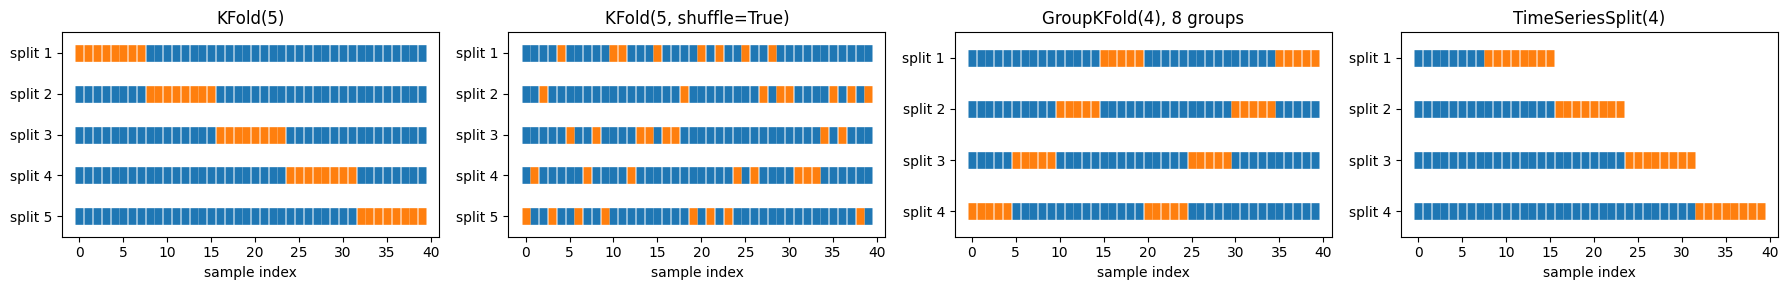

In [5]:
def plot_cv_indices(cv, X, y=None, groups=None, ax=None, title=""):
    # Training samples blue, validation samples orange, unused samples white
    ax = ax or plt.gca()
    n_splits = cv.get_n_splits(X, y, groups)
    for i, (train_idx, val_idx) in enumerate(cv.split(X, y, groups)):
        ax.scatter(train_idx, [i] * len(train_idx), marker="_", lw=12, color="tab:blue")
        ax.scatter(val_idx, [i] * len(val_idx), marker="_", lw=12, color="tab:orange")
    ax.set(yticks=range(n_splits), yticklabels=[f"split {i + 1}" for i in range(n_splits)],
           ylim=(n_splits - 0.5, -0.5), xlabel="sample index", title=title)


n_demo = 40
X_demo = np.arange(n_demo).reshape(-1, 1)
groups_demo = np.repeat(np.arange(8), 5)  # 8 groups (e.g. customers) with 5 rows each

fig, axes = plt.subplots(1, 4, figsize=(18, 3))
plot_cv_indices(KFold(n_splits=5), X_demo, ax=axes[0], title="KFold(5)")
plot_cv_indices(KFold(n_splits=5, shuffle=True, random_state=0), X_demo, ax=axes[1], title="KFold(5, shuffle=True)")
plot_cv_indices(GroupKFold(n_splits=4), X_demo, groups=groups_demo, ax=axes[2], title="GroupKFold(4), 8 groups")
plot_cv_indices(TimeSeriesSplit(n_splits=4), X_demo, ax=axes[3], title="TimeSeriesSplit(4)")
plt.tight_layout()
plt.show()

## 0.3 Baselines compared with cross-validation

`cross_validate` returns training and validation scores for several metrics at once; comparing them shows over- and underfitting. Scikit-learn always *maximises* a score, so error metrics come with a minus sign (`neg_root_mean_squared_error`).

In [6]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

candidates = {
    "Dummy (mean)": DummyRegressor(strategy="mean"),
    "Linear regression": make_pipeline(StandardScaler(), LinearRegression()),
    "Decision tree (full depth)": DecisionTreeRegressor(random_state=RANDOM_STATE),
    "Decision tree (max_depth=8)": DecisionTreeRegressor(max_depth=8, random_state=RANDOM_STATE),
    "Random forest": RandomForestRegressor(n_estimators=100, min_samples_leaf=2, n_jobs=-1, random_state=RANDOM_STATE),
}

rows = []
for name, model in candidates.items():
    res = cross_validate(model, X_tr, y_tr, cv=cv, scoring=["neg_root_mean_squared_error", "r2"],
                         return_train_score=True, n_jobs=-1)
    rows.append({
        "model": name,
        "train RMSE": -res["train_neg_root_mean_squared_error"].mean(),
        "CV RMSE": -res["test_neg_root_mean_squared_error"].mean(),
        "CV RMSE std": res["test_neg_root_mean_squared_error"].std(),
        "CV R2": res["test_r2"].mean(),
        "fit time [s]": res["fit_time"].mean(),
    })
cv_results = pd.DataFrame(rows).set_index("model").round(3)
cv_results

,train RMSE,CV RMSE,CV RMSE std,CV R2,fit time [s]
model,,,,,
Dummy (mean),1.155,1.155,0.008,-0.000,0.004
Linear regression,0.720,0.721,0.007,0.610,0.014
Decision tree (full depth),0.000,0.737,0.018,0.593,0.171
Decision tree (max_depth=8),0.563,0.654,0.006,0.680,0.081
Random forest,0.240,0.509,0.011,0.806,4.687


Questions:
* Which models overfit? Compare the training and the CV RMSE.
* Is the linear model good enough? What would you try to improve it (feature engineering, interactions, log of the target)?
* Why do we need the dummy model at all?

## 0.4 Data leakage: preprocessing belongs inside the cross-validation

Every step that learns something from the data (means of a scaler, medians of an imputer, selected features, target encoding, oversampling, ...) must be fitted **only on the training folds**. Otherwise information from the validation fold leaks into the model and the CV score is too optimistic. A `Pipeline` guarantees this: `cross_validate` refits the whole pipeline in every split.

An extreme example: pure noise, 100 samples and 5 000 random features. There is nothing to learn, so the honest $R^2$ is about 0 or below.

In [7]:
from sklearn.feature_selection import SelectKBest, f_regression

rng = np.random.default_rng(0)
X_noise = rng.normal(size=(100, 5000))
y_noise = rng.normal(size=100)

# WRONG: select the 20 "best" features on the full data set, then cross-validate
X_selected = SelectKBest(f_regression, k=20).fit_transform(X_noise, y_noise)
wrong = cross_val_score(LinearRegression(), X_selected, y_noise, cv=5, scoring="r2")

# RIGHT: feature selection is a step of the pipeline and is refitted in every fold
pipe = make_pipeline(SelectKBest(f_regression, k=20), LinearRegression())
right = cross_val_score(pipe, X_noise, y_noise, cv=5, scoring="r2")

print(f"selection outside CV:      R2 = {wrong.mean():.2f}")
print(f"selection inside pipeline: R2 = {right.mean():.2f}")

selection outside CV:      R2 = 0.43
selection inside pipeline: R2 = -0.61


Other common sources of leakage:
* features that are known only after the predicted event (e.g. the number of insurance claims when predicting a claim),
* duplicated rows in both train and test,
* target encoding or imputation computed on the full data set,
* a random split of time series (the model sees the future),
* scaling the whole data set before the split (a small effect for a scaler, but a bad habit).

## 0.5 Hyperparameter tuning and nested cross-validation

Hyperparameters (tree depth, number of trees, learning rate, ...) are chosen by cross-validation on the training set:
- `GridSearchCV` tries all combinations (fine for small grids),
- `RandomizedSearchCV` samples `n_iter` combinations from given distributions (better for many hyperparameters),
- successive halving (`HalvingGridSearchCV`, `HalvingRandomSearchCV`) and Bayesian optimisation (Optuna, see the end of this notebook) spend the compute on promising candidates.

The best CV score of a search is itself **optimistically biased** – it is the maximum of many noisy estimates. An unbiased estimate needs data that were not used for the selection: the held-out test set, or **nested CV** (an inner CV for tuning inside an outer CV for evaluation).

In [8]:
param_grid = {"max_depth": [4, 6, 8, 10, 12, 15, 20], "min_samples_leaf": [1, 5, 20, 50]}
inner_cv = KFold(n_splits=3, shuffle=True, random_state=1)
outer_cv = KFold(n_splits=5, shuffle=True, random_state=2)

search = GridSearchCV(DecisionTreeRegressor(random_state=RANDOM_STATE), param_grid, cv=inner_cv,
                      scoring="neg_root_mean_squared_error", n_jobs=-1)
search.fit(X_tr, y_tr)
print("best params:", search.best_params_)
print(f"best inner CV RMSE: {-search.best_score_:.3f}")

nested = cross_val_score(search, X_tr, y_tr, cv=outer_cv, scoring="neg_root_mean_squared_error", n_jobs=-1)
print(f"nested CV RMSE: {-nested.mean():.3f} +- {nested.std():.3f}")

best params: {'max_depth': 15, 'min_samples_leaf': 20}
best inner CV RMSE: 0.622


nested CV RMSE: 0.617 +- 0.011


In [9]:
# Last step of the workflow: GridSearchCV has already refitted the best model on the whole
# training set (refit=True), so we evaluate it ONCE on the test set
y_pred_te = search.predict(X_te)
print(f"test RMSE: {root_mean_squared_error(y_te, y_pred_te):.3f}, test R2: {r2_score(y_te, y_pred_te):.3f}")

test RMSE: 0.604, test R2: 0.724


Questions:
* Compare the best inner CV score, the nested CV score and the test score. Here, with 16 000 rows and only a few candidate models, the selection bias is small, and the nested estimate can even be slightly worse because the inner models are trained on less data. When does the optimism of `best_score_` become serious? (Small data, many candidates, large differences between folds.)
* Is the best value of a hyperparameter at the edge of the grid? What does it mean and what would you do?

### Other options and how it used to be done
- **Simple hold-out (train/validation/test)** is still the norm for very large data and for deep learning, where k-fold is too expensive.
- **Leave-one-out** and **bootstrap (.632) estimators** were popular for very small data sets; today repeated k-fold is the usual choice.
- **Out-of-bag (OOB) error** of bagging and random forests (Section 2) is a free alternative to CV for these models.
- Older code used the modules `sklearn.cross_validation` and `sklearn.grid_search` (removed in scikit-learn 0.20; everything is now in `sklearn.model_selection`), manual loops over `KFold` indices and scaling of the whole data set before the split. Today `Pipeline` + `cross_validate` / `*SearchCV` do this correctly for you.
- **Time series** need `TimeSeriesSplit` or a rolling-origin evaluation (see the time series lecture).
- Information criteria (AIC, BIC) and adjusted $R^2$ from classical statistics select linear models without a validation set, but only within one parametric model family.

# 1. Decision Trees

* A tree-shaped ML method that can cope with both classification and regression tasks.
  * Classification Tree: A decision tree that performs classification (predicts a categorical response).
  * Regression Tree: A decision tree that performs regression (predicts a numeric response).
* Powerful algorithms, easy to train and fit huge datasets with mixed predictors (numeric and categorical).
* Easily interpretable method by humans (white box model with similar approach how humans make decisions - one step at a time). Harder, but possible for large trees too.
* **The cornerstone of Random Forests** and other ensemble methods.


Most implementation in this lecture is from scikit-learn library: https://scikit-learn.org/stable/modules/tree.html


## Motivation and first touch


**Personal view:** Tree-based gradient boosting remains a strong default for structured data, but real-world success still depends on informed feature engineering, reliable validation, and transparent communication of assumptions.

**Simplified view:**


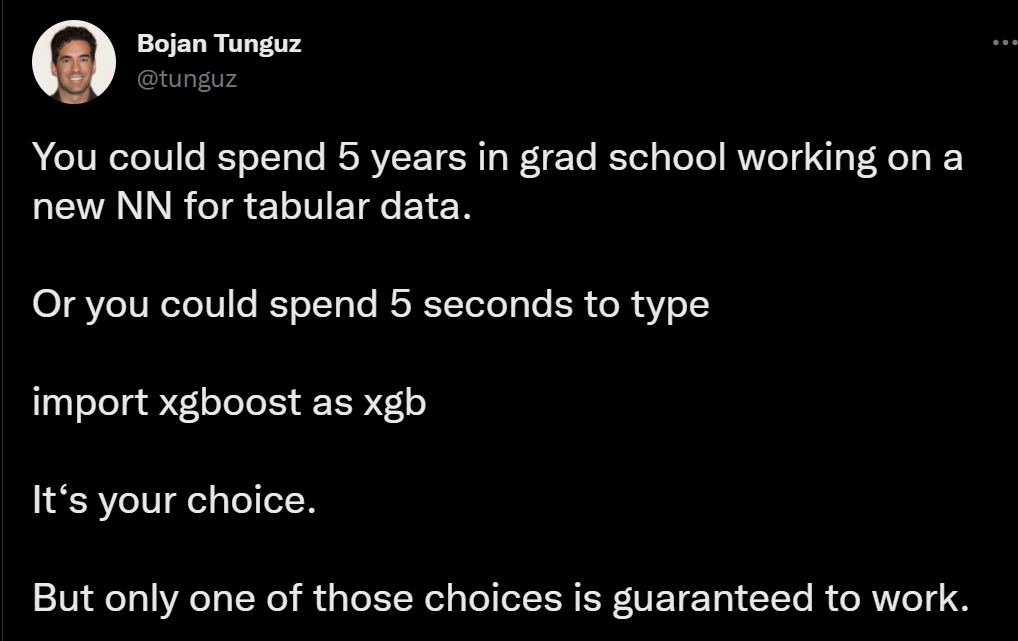

Before diving into gradient boosting libraries, revisit how plain decision trees partition the feature space.

In [10]:
# Load iris dataset
iris = load_iris()
iris_pd = pd.DataFrame(data=np.c_[iris['data'], iris['target']],
                       columns=iris['feature_names'] + ['target'])
# Print descriptive statistics of the dataset
print(iris_pd.describe())

       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)      target  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    0.000000  
50%            1.300000    1.000000  
75%            1.800000    2.000000  
max            2.500000    2.000000  


Let's take only 2 dimensional data and use Decision Tree for Classification as a "black box" for a moment.

In [11]:
X = iris.data[:, 2:] # Let's take only petal length and width into account
y = iris.target

tree_clf0 = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf0.fit(X, y)

,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


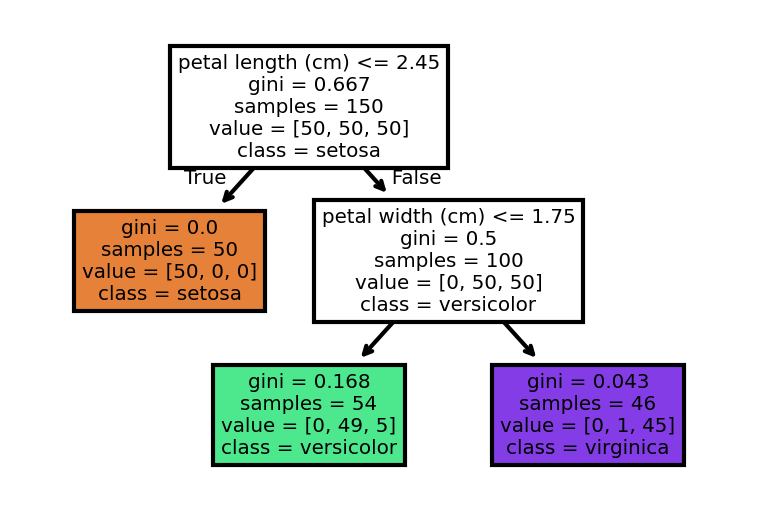

In [12]:
# To see the graphical visualisation from graphiz as a dot file check:
#https://towardsdatascience.com/visualizing-decision-trees-with-python-scikit-learn-graphviz-matplotlib-1c50b4aa68dc

fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (3,2), dpi=300)
tree.plot_tree(tree_clf0,
               feature_names =['petal length (cm)','petal width (cm)'],
               class_names=['setosa', 'versicolor', 'virginica'],
               filled = True);

### ✍🏼 Exercise 1.1

We mentioned that Decision Tree is easy to interpret and it can easily estimate the probability that new observation belongs to a particular class `k`:

Suppose we found a flower with folowing parameters:
* `petal length = 4cm `
* `petal width = 1.7cm`

What is the probability that this flower corresponds to given class (`setosa`,`versicolor`,`virginica`)?


In [13]:
# Your turn:
p_setosa = 0/54
p_versicolor = 49/54
p_virginica = 5/54
print([[p_setosa,p_versicolor,p_virginica]])
tree_clf0.predict_proba([[4,1.7]])


[[0.0, 0.9074074074074074, 0.09259259259259259]]


array([[0.        , 0.90740741, 0.09259259]])

Import some help functions from the Python Data Science Handbook to better visualization of the tree classifier and its boundaries.

In [14]:
%%file helpers.py
# Helpers for interactive tree visualisation (auto-generated)
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact
from matplotlib.axes import Axes
from sklearn.tree import DecisionTreeClassifier
from typing import Any, Optional, Tuple


def visualize_tree(
    estimator: DecisionTreeClassifier,
    X: np.ndarray,
    y: np.ndarray,
    boundaries: bool = True,
    xlim: Optional[Tuple[float, float]] = None,
    ylim: Optional[Tuple[float, float]] = None,
    ax: Optional[Axes] = None,
) -> Axes:
    '''Fit the estimator on `(X, y)` and plot decision boundaries for two features.'''
    ax = ax or plt.gca()
    scatter = ax.scatter(
        X[:, 0],
        X[:, 1],
        c=y,
        s=30,
        cmap='viridis',
        clim=(y.min(), y.max()),
        zorder=3,
    )
    scatter.set_label('training data')
    ax.set_xlabel('feature 1')
    ax.set_ylabel('feature 2')
    if xlim is None:
        xlim = ax.get_xlim()
    if ylim is None:
        ylim = ax.get_ylim()
    estimator.fit(X, y)
    xx, yy = np.meshgrid(
        np.linspace(*xlim, num=200),
        np.linspace(*ylim, num=200),
    )
    mesh_predictions = estimator.predict(np.c_[xx.ravel(), yy.ravel()])
    mesh_predictions = mesh_predictions.reshape(xx.shape)
    ax.contourf(
        xx,
        yy,
        mesh_predictions,
        alpha=0.3,
        levels=np.arange(len(np.unique(y)) + 1) - 0.5,
        cmap='viridis',
    )
    if boundaries:
        def plot_boundaries(index: int, x_span: Tuple[float, float], y_span: Tuple[float, float]) -> None:
            if index < 0:
                return
            tree = estimator.tree_
            threshold = tree.threshold[index]
            feature_index = tree.feature[index]
            if feature_index == 0:
                ax.plot([threshold, threshold], y_span, '-k', zorder=2)
                plot_boundaries(tree.children_left[index], (x_span[0], threshold), y_span)
                plot_boundaries(tree.children_right[index], (threshold, x_span[1]), y_span)
            elif feature_index == 1:
                ax.plot(x_span, [threshold, threshold], '-k', zorder=2)
                plot_boundaries(tree.children_left[index], x_span, (y_span[0], threshold))
                plot_boundaries(tree.children_right[index], x_span, (threshold, y_span[1]))
        plot_boundaries(0, xlim, ylim)
    ax.set(xlim=xlim, ylim=ylim)
    return ax


def plot_tree_interactive(X: np.ndarray, y: np.ndarray) -> Any:
    '''Create an interactive widget to explore tree depth on a toy dataset.'''
    def interactive_tree(depth: int) -> Axes:
        clf = DecisionTreeClassifier(max_depth=depth, random_state=0)
        return visualize_tree(clf, X, y)
    return interact(interactive_tree, depth=list(range(1, 11)))


def randomized_tree_interactive(X: np.ndarray, y: np.ndarray) -> None:
    '''Illustrate how random sampling changes the learned boundaries.'''
    n_samples = int(0.75 * X.shape[0])
    xlim = (X[:, 0].min(), X[:, 0].max())
    ylim = (X[:, 1].min(), X[:, 1].max())

    def fit_randomized_tree(random_state: int = 0) -> None:
        clf = DecisionTreeClassifier(max_depth=15, random_state=random_state)
        rng = np.random.default_rng(random_state)
        indices = rng.permutation(X.shape[0])[:n_samples]
        visualize_tree(
            clf,
            X[indices],
            y[indices],
            boundaries=False,
            xlim=xlim,
            ylim=ylim,
        )

    interact(fit_randomized_tree, random_state=list(range(0, 501, 50)))


Overwriting helpers.py


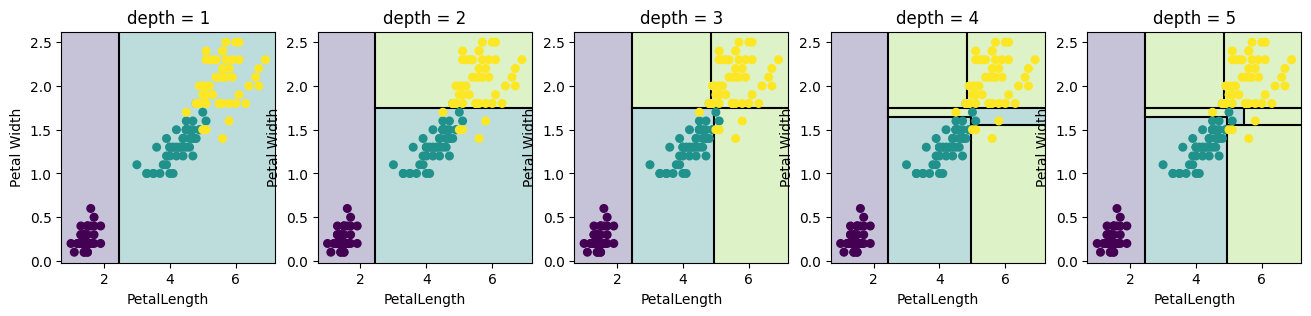

In [15]:
from helpers import visualize_tree

maximal_depth = 5
fig, ax = plt.subplots(1, maximal_depth, figsize=(16, 3))
#fig.subplots_adjust(left=0.02, right=0.98, wspace=0.1)
# Set common labels


#X, y = make_blobs(n_samples=300, centers=4,
#                  random_state=0, cluster_std=1.0)

for axi, depth in zip(ax, range(1, maximal_depth+1)):
    model = DecisionTreeClassifier(max_depth=depth,  random_state=42)
    visualize_tree(model, X, y, ax=axi)
    axi.set_title('depth = {0}'.format(depth))
    axi.set_xlabel('PetalLength')
    axi.set_ylabel('Petal Width')

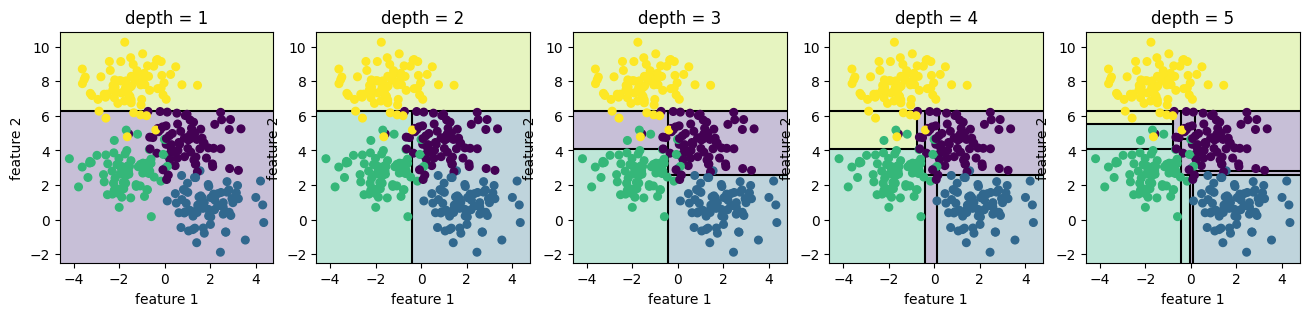

In [16]:
maximal_depth = 5
fig, ax = plt.subplots(1, maximal_depth, figsize=(16, 3))

X_blob, y_blob = make_blobs(n_samples=300, centers=4,
                  random_state=0, cluster_std=1.0)

for axi, depth in zip(ax, range(1, maximal_depth+1)):
    model = DecisionTreeClassifier(max_depth=depth,  random_state=42)
    visualize_tree(model, X_blob, y_blob, ax=axi)
    axi.set_title('depth = {0}'.format(depth))
    axi.set_xlabel('feature 1')
    axi.set_ylabel('feature 2')

### ✍🏼 Exercise 1.2

Increase the maximal depth and answer the following questions:
* At which depth does the tree start to overfit the blobs data?
* Why are the decision boundaries always parallel to the axes?
* How do the boundaries change when the tree is fitted on a slightly different sample? (Try `randomized_tree_interactive(X_blob, y_blob)` from `helpers.py`.)

Task:
* Implement simple binary decision tree for XOR Problem by hand (if and else statements)

http://arogozhnikov.github.io/2016/07/05/gradient_boosting_playground.html

In [17]:
x = 1
y = 1

def logical_xor(x: float, y: float) -> bool:
    """Return the exclusive OR of two binary-like inputs."""
    return bool(x) ^ bool(y)

def dt_xor(x: float, y: float) -> bool:
    """Replicate XOR logic using simple threshold-based splits."""
    if x > 0.5:
        return y <= 0.5
    return y > 0.5

print(dt_xor(x, y))
print(logical_xor(x, y))


False
False


## How to build a binary tree?

To build a decision tree model, we take a greedy approach that partitions  the input space and then fit very
simple models to predict the output in each piece:

1. Start with an empty tree.
2. Choose the optimal predictor on which to split and choose the optimal threshold value for splitting by applying a splitting criterion.
3. Recurse on on each new node until stopping condition is met.


The partition in binary tree is described using a "cuts”, which recursively splits the space.

**Methods of building a evaluating a tree can differ by**:
* The class of possible ways to split the space at each node (generally a linear orthogonal splits parallel to the axes of the space).
* The class of predictors within the partitions (generally simply constants).
* The algorithm for making the partitions.



### Algorithms
There are many different algorithms, but all are based on **greedily** constructing a partition. The most used algorithm is CART, introduced by
Leo Breiman and his colleagues  
Breiman, L., J. Friedman, R. Olshen, and C. Stone, 1984: Classification and regression trees. Wadsworth Books, 358.  
(https://www.stat.berkeley.edu/~breiman/)

Other well known algorithms are ID3, C4.5 or C5.0 all created by Ross Quinlan.

Some of the differences between CART and C4.5 are:
* Splitings in CART are always binary, but C4.5 allows two or more outcomes.
* The original CART algorithm uses the Gini Impurity, whereas C4.5 use Entropy.
* Different approach to pruning and missing data.


Rules based on variables’ values are selected to get the best split to differentiate observations based on the dependent variable.

Once a rule is selected and splits a node into two, the same process is applied to each “child” node (i.e. it is a recursive procedure).

Splitting stops when the algorithm detects no further gain can be made, or some pre-set stopping rules are met. Or the data are split as much as possible and then the tree is later pruned.



#### How to select the splits and how to control complexity?

We focus on Classification and Regression Tree (CART) algorithm.

The growing of the tree (training) starts by splitting the training set into 2 subsets using a single feature $k$ and a threshold $t_k$.

There are several cost functions, how to choose the pair $(k,t_k)$.

****

#### CART algorithm cost functions for classification:


For classification, CART algorithm minimize following cost functions (splitting criteria) :

* **Gini Impurity in node $i$**:  
Gini Impurity is a measure of how often a randomly chosen element from the set would be incorrectly labeled if it was randomly labeled according to the distribution of labels in the subset.  
$J(k,t_k) = \frac{m_{2i}}{m} G_{2i} +  \frac{m_{2i+1}}{m} G_{2i+1} =  \frac{m_{2i}}{m} \sum_{j=1}^n ( p_{2i,j} (1- p_{2i,j})) +  \frac{m_{2i+1}}{m} \sum_{j=1}^n ( p_{2i+1,j} (1- p_{2i+1,j})) = \frac{m_{2i}}{m} (1- \sum_{j=1}^n p_{2i,j}^2) +  \frac{m_{2i+1}}{m} (1- \sum_{j=1}^n p_{2i+1,j}^2),$  
where $p_{i,j}$ is the ratio of class $j$ instances among the training instances in the $i^{th}$ node and $m_i$ is the number of instances in this node.  
Gini Impurity  reaches zero when all cases in the node fall into a single target category.

* **Entropy in node $i$**:  
Entropy is a measure of the amount of uncertainty in the data.
$J(k,t_k) = \frac{m_{2i}}{m} H_{2i} +  \frac{m_{2i+1}}{m} H_{2i+1} =  \frac{m_{2i}}{m} (- \sum_{j=1}^n p_{2i,j} log(p_{2i,j})) +  \frac{m_{2i+1}}{m} (- \sum_{j=1}^n p_{2i+1,j} log(p_{2i+1,j})).$  
Entropy of the node is zero when all instances in the node is perfectly classified.


* **Misclassification Error**  
$J(k,t_k) =  \frac{m_{2i}}{m} (1 - p_{2i,j(j)}) +  \frac{m_{2i+1}}{m} (1 - p_{2i+1,j(j)}),$  
where $p_{i,j(j)}$ is the ratio of right assigned instances in the $i^{th}$ node. Note: (Accuracy = 1 - Misclassification Rate).



Text(0, 0.5, 'Metric value')

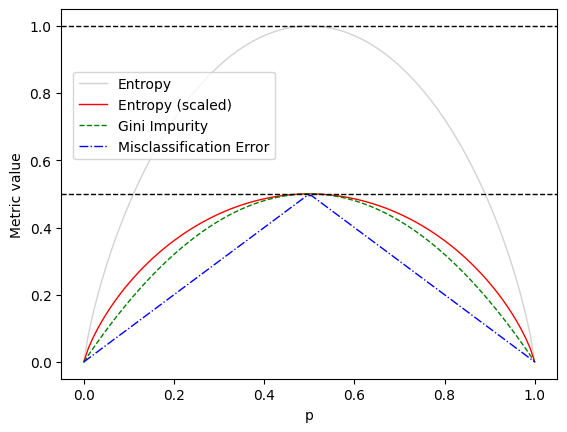

In [18]:
# Utility functions for impurity measures

def gini(p: np.ndarray) -> np.ndarray:
    """Compute the Gini impurity for Bernoulli probability `p`."""
    p = np.asarray(p)
    return 2 * p * (1 - p)

def entropy(p: np.ndarray, *, base: float = 2.0) -> np.ndarray:
    """Compute the Shannon entropy for Bernoulli probability `p`."""
    p = np.asarray(p)
    eps = np.finfo(float).eps
    p = np.clip(p, eps, 1 - eps)
    return -(p * np.log(p) + (1 - p) * np.log(1 - p)) / np.log(base)

def classification_error(p: np.ndarray) -> np.ndarray:
    """Return the misclassification error for Bernoulli probability `p`."""
    p = np.asarray(p)
    return 1 - np.maximum(p, 1 - p)

x = np.linspace(0.0, 1.0, 100)
ent = entropy(x)
scaled_ent = 0.5 * ent
c_err = classification_error(x)

fig = plt.figure()
ax = plt.subplot(111)
for curve, label, linestyle, colour in zip(
    [ent, scaled_ent, gini(x), c_err],
    ['Entropy', 'Entropy (scaled)', 'Gini Impurity', 'Misclassification Error'],
    ['-', '-', '--', '-.'],
    ['lightgray', 'red', 'green', 'blue'],
):
    ax.plot(x, curve, label=label, linestyle=linestyle, lw=1, color=colour)
ax.legend(loc='upper left', bbox_to_anchor=(0.01, 0.85), ncol=1, fancybox=True, shadow=False)
ax.axhline(y=0.5, linewidth=1, color='k', linestyle='--')
ax.axhline(y=1.0, linewidth=1, color='k', linestyle='--')
ax.set_xlabel('p')
ax.set_ylabel('Metric value')


Hint: Use concave cost functions such as Entropy or Gini. Misclassification Error can stuck in case of zero information gain.

Question: Does a child node always have a lower value of the cost function (Entropy/Gini/...) than its parent node?

Calculate the information gain in example from the beginning:

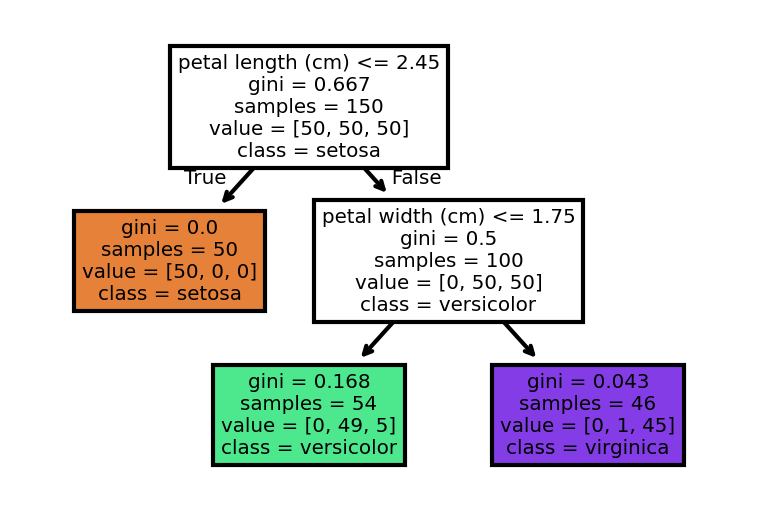

In [19]:
fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (3,2), dpi=300)
tree.plot_tree(tree_clf0,
               feature_names =['petal length (cm)','petal width (cm)'],
               class_names=['setosa', 'versicolor', 'virginica'],
               filled = True);

For more detail explanation: https://www.youtube.com/watch?v=cLWZVinpAu0

#### CART algorithm cost functions for regression:


For regression, CART algorithm minimizes the following cost function:

* **MSE in node $i$**:
$J(k,t_k) = \frac{m_{2i}}{m} MSE_{2i} + \frac{m_{2i+1}}{m} MSE_{2i+1}, \qquad MSE_{node} = \frac{1}{m_{node}} \sum_{l \in node} (\hat{y}_{node} - y^{(l)})^2,$
where $m$ is the number of instances in the parent node, $m_{node}$ in the child node and $\hat{y}_{node}$ is the average of the target in the node,
$\hat{y}_{node} = \frac{1}{m_{node}} \sum_{l \in node} y^{(l)}$.

$MSE$ can be replaced by $MAE$ (`criterion="absolute_error"`, the prediction is then the median), Friedman MSE or Poisson deviance.

Since CART is a greedy algorithm, it searches for the optimal split at each level separately. That's why it often produces only a "reasonably good" locally optimal tree and not the global optimum.

Finding the optimal tree is an NP-complete problem.

Training can be sped up by considering only a random subset of features at each split (`max_features < n_features`) or by drawing random thresholds (`splitter="random"`). Histogram-based implementations (`HistGradientBoosting`, XGBoost, LightGBM) bin the features first and evaluate only the bin edges. (Older scikit-learn versions had a `presort` option; it was removed in version 0.24.)

Scikit-learn uses an optimised version of the CART algorithm. Single trees and random forests in scikit-learn still need numeric input, so categorical features have to be encoded (`OneHotEncoder`, `OrdinalEncoder`, `TargetEncoder`). Native support for categorical features exists in `HistGradientBoostingRegressor/Classifier` (`categorical_features="from_dtype"`), LightGBM and CatBoost.

## New Data - prediction in terminal nodes.

* Regression task:
The mean value of all points in each terminal node is
the representative of that terminal node.

* Classification task:
The class with the most occurrences in the node is selected.

* Prediction:
New observations are dropped down the tree, end in a terminal node and get its associated response.

* Missing values:
The original CART algorithm deals with missing values through **surrogate splits**: other features which best mimic how the chosen feature sends instances to the left or right child (if no useful surrogate is found, the majority rule is used).
Scikit-learn does not implement surrogates. Since version 1.3 its trees support missing values natively: during training the splitter learns for every split whether samples with a missing value go to the left or to the right child. XGBoost, LightGBM and `HistGradientBoosting` use the same idea ("default direction").

## Regularization, pruning, stability

Decision trees tends to overtrain, to avoid that (i.e. avoid overfitting the training dataset) we have to apply regularization techniques.

* What kind of regularization techniques do you know?
* Describe the relation between Variance, Bias, and Model Complexity.


If we don’t terminate the decision tree learning algorithm manually, the tree will continue to grow until each terminate node  contains exactly one training point (100% training accuracy, $R^2 = 1$, $mse = 0$ ).  Very deep trees have low bias but high variance (can overfit). Complex trees are also harder
to interpret and more computationally expensive to train.

* Example of **stopping conditions**, do not split a node if:
  * all instances in the region belong to the same class
  * the number of instances in the node will be smaller than given threshold  
  * the total number of leaves in the tree will exceed given threshold
  * and others
  
Alternative approach to **early stopping** is to built complete tree and then prune back.




Unpruned decision trees are usually high variance and low bias models.

**Pruning**  
Minimal cost-complexity pruning is an algorithm used to prune a tree to avoid overfitting and it is parameterized by measure that is balance of performance and efficiency:   
$$ C(T) = Error(T) + \alpha |T|,$$
where $T$ is a decision subtree,  $|T|$ is the number of leaves in the tree
and $\alpha$ is the parameter for penalizing model complexity.

Algorithm:
 1. Start with a full tree $T_0$ (terminal nodes with one instance).
 2. Replace a subtree in $T_0$ with a leaf node to obtain a pruned tree $T_1$. This subtree should be selected to minimize $\frac{Error(T_0) - Error(T_1)}{|T_0| - |T_1|}$
 3. Iterate pruning process to obtain $T_0, \ T_1, \ \ldots, T_L$ where $T_L$ is the root tree.
 4. Select the optimal tree $T_i$ by cross validation.

The computing cost complexity is equivalent to explicitly optimizing C at each step.
Description of scikit-learn pruning method: https://scikit-learn.org/stable/modules/tree.html#minimal-cost-complexity-pruning

Let's see which hyperparameters we can set and how the **Regression** tree will behave.

In [20]:
# Quadratic data set + noise
rng = np.random.default_rng(42)
m = 200
X = rng.random((m, 1))
y = 4 * (X[:, 0] - 0.5) ** 2 + rng.normal(scale=0.1, size=m)

# Split first: every model below is fitted on the training part only
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=RANDOM_STATE)

tree_reg1 = DecisionTreeRegressor(max_depth=2, random_state=RANDOM_STATE)
tree_reg2 = DecisionTreeRegressor(max_depth=3, criterion="squared_error", random_state=RANDOM_STATE)  # squared_error = former "mse"
tree_reg1.fit(X_train, y_train)
tree_reg2.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


[Text(0.5, 0.875, 'x1 <= 0.843\nsquared_error = 0.089\nsamples = 150\nvalue = 0.323'),
 Text(0.25, 0.625, 'x1 <= 0.208\nsquared_error = 0.064\nsamples = 128\nvalue = 0.252'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'x1 <= 0.073\nsquared_error = 0.037\nsamples = 35\nvalue = 0.556'),
 Text(0.0625, 0.125, 'squared_error = 0.025\nsamples = 7\nvalue = 0.83'),
 Text(0.1875, 0.125, 'squared_error = 0.016\nsamples = 28\nvalue = 0.488'),
 Text(0.375, 0.375, 'x1 <= 0.748\nsquared_error = 0.026\nsamples = 93\nvalue = 0.137'),
 Text(0.3125, 0.125, 'squared_error = 0.015\nsamples = 76\nvalue = 0.085'),
 Text(0.4375, 0.125, 'squared_error = 0.012\nsamples = 17\nvalue = 0.368'),
 Text(0.75, 0.625, 'x1 <= 0.931\nsquared_error = 0.031\nsamples = 22\nvalue = 0.739'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'x1 <= 0.895\nsquared_error = 0.009\nsamples = 12\nvalue = 0.601'),
 Text(0.5625, 0.125, 'squared_error = 0.006\nsamples = 6\nvalue = 0.541'),
 Text(0.6875, 0.125, 'squared_error 

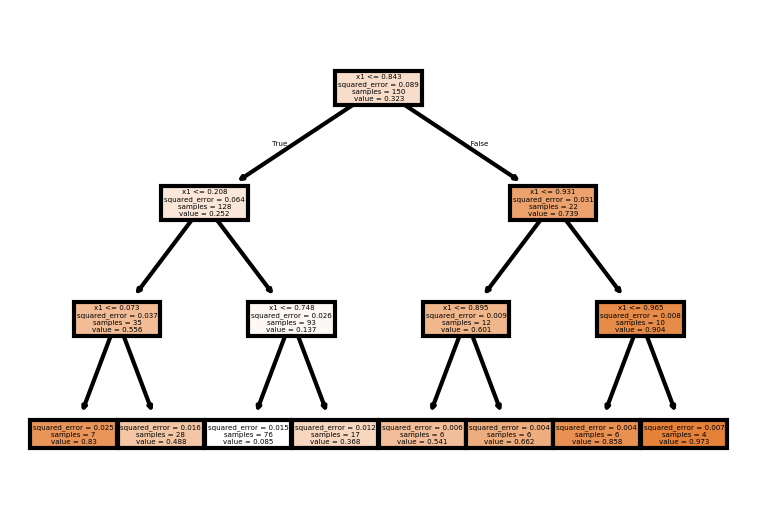

In [21]:
fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (3,2), dpi=300)
tree.plot_tree(tree_reg2,
               feature_names =['x1'],
               filled = True)

In [22]:
def plot_regression_predictions(tree_reg, X, y, axes=(-0.5, 1.5, -0.2, 1.5), ylabel="$y$"):
    """Plot training data and fitted predictions for a one-dimensional tree regressor."""
    x1 = np.linspace(axes[0], axes[1], 500).reshape(-1, 1)
    y_pred = tree_reg.predict(x1)
    plt.axis(axes)
    plt.xlabel("$x_1$", fontsize=18)
    if ylabel:
        plt.ylabel(ylabel, fontsize=18, rotation=0)
    plt.plot(X, y, "b.", label='training samples')
    plt.plot(x1, y_pred, "r.-", linewidth=2, label=r"$\hat{y}$")


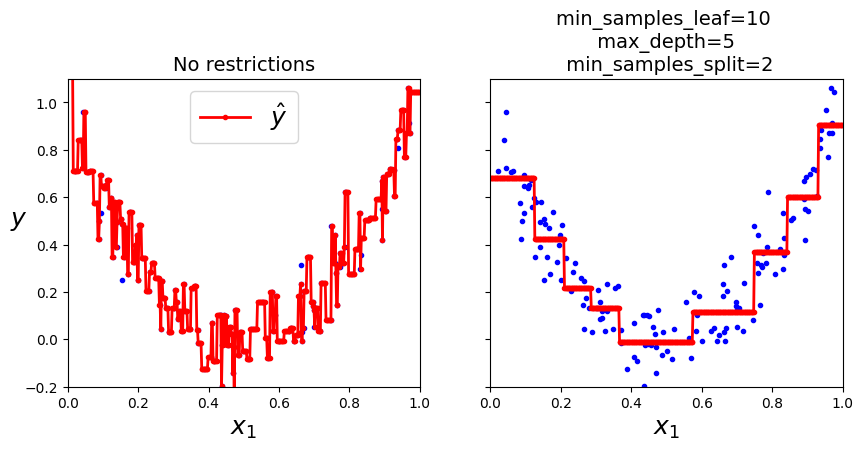

In [23]:
tree_reg3 = DecisionTreeRegressor(random_state=42)
tree_reg4 = DecisionTreeRegressor(random_state=42,
                                  min_samples_leaf=10,
                                  max_depth = 5,
                                  min_samples_split = 2)
tree_reg3.fit(X_train, y_train)
tree_reg4.fit(X_train, y_train)

x1 = np.linspace(0, 1, 500).reshape(-1, 1)
y_pred1 = tree_reg3.predict(x1)
y_pred2 = tree_reg4.predict(x1)

fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)

plt.sca(axes[0])
plt.plot(X_train, y_train, "b.")
plt.plot(x1, y_pred1, "r.-", linewidth=2, label=r"$\hat{y}$")
plt.axis([0, 1, -0.2, 1.1])
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", fontsize=18, rotation=0)
plt.legend(loc="upper center", fontsize=18)
plt.title("No restrictions", fontsize=14)

plt.sca(axes[1])
plt.plot(X_train, y_train, "b.")
plt.plot(x1, y_pred2, "r.-", linewidth=2, label=r"$\hat{y}$")
plt.axis([0, 1, -0.2, 1.1])
plt.xlabel("$x_1$", fontsize=18)
plt.title("min_samples_leaf={samples} \n max_depth={depth} \n min_samples_split={split}"
          .format(samples = tree_reg4.min_samples_leaf,
                  depth = tree_reg4.max_depth,
                  split = tree_reg4.min_samples_split), fontsize=14)

plt.show()

**Cost-complexity pruning path** – fit a tree for each candidate $\alpha$ and compare the training and test scores:

Number of nodes in the last tree is: 1 with ccp_alpha: 0.029742370541761175


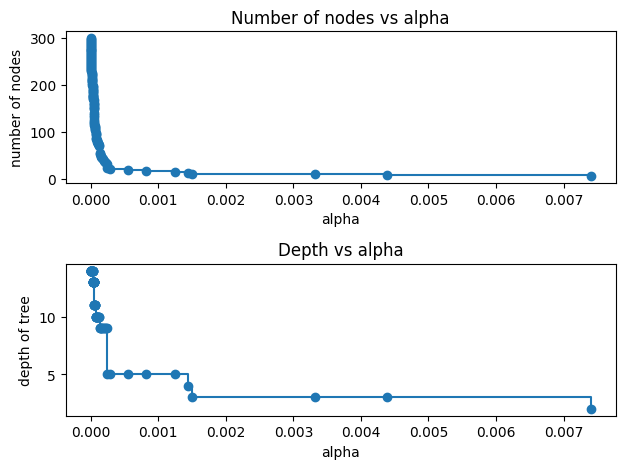

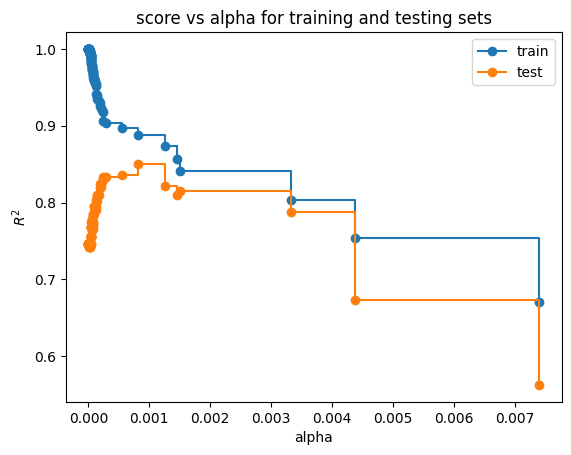

In [24]:
clf_all = DecisionTreeRegressor(random_state=0)
path = clf_all.cost_complexity_pruning_path(X_train, y_train)

ccp_alphas, impurities = path.ccp_alphas, path.impurities

clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeRegressor(random_state=0, ccp_alpha=ccp_alpha)
    clf.fit(X_train, y_train)
    clfs.append(clf)
print(
    "Number of nodes in the last tree is: {} with ccp_alpha: {}".format(
        clfs[-1].tree_.node_count, ccp_alphas[-1]
    )
)

clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

node_counts = [clf.tree_.node_count for clf in clfs]
depth = [clf.tree_.max_depth for clf in clfs]
fig, ax = plt.subplots(2, 1)
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
fig.tight_layout()


# r2_score(y_true, y_pred): the order of the arguments matters
train_scores = [r2_score(y_train, clf.predict(X_train)) for clf in clfs]
test_scores = [r2_score(y_test, clf.predict(X_test)) for clf in clfs]


fig, ax = plt.subplots()
ax.set_xlabel("alpha")
ax.set_ylabel("$R^2$")
ax.set_title("score vs alpha for training and testing sets")
ax.plot(ccp_alphas, train_scores, marker="o", label="train", drawstyle="steps-post")
ax.plot(ccp_alphas, test_scores, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

**Find optimal depth of trees**


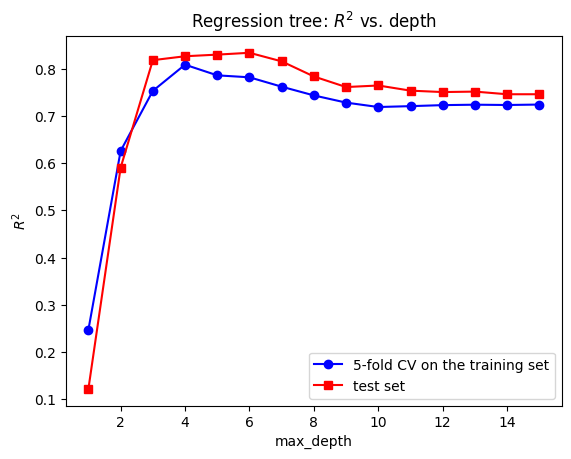

In [25]:
depths = range(1, 16)
cv_r2, test_r2 = [], []
for d in depths:
    model = DecisionTreeRegressor(max_depth=d, random_state=RANDOM_STATE)
    cv_r2.append(cross_val_score(model, X_train, y_train, cv=5, scoring="r2").mean())
    test_r2.append(r2_score(y_test, model.fit(X_train, y_train).predict(X_test)))

plt.plot(depths, cv_r2, "b-o", label="5-fold CV on the training set")
plt.plot(depths, test_r2, "r-s", label="test set")
plt.xlabel("max_depth")
plt.ylabel("$R^2$")
plt.title("Regression tree: $R^2$ vs. depth")
plt.legend()
plt.show()

Question: Why doesn't $R^2$ converge to 1 as the number of layers increases?

## Decision tree Playground

Try to fit models, plot results, play with regularization ...

In [26]:
# Check results from previous tree
print(mean_squared_error(y_test, tree_reg1.predict(X_test))) # max_depth 2
print(mean_squared_error(y_test, tree_reg2.predict(X_test))) # max_depth 3
print(mean_squared_error(y_test, tree_reg3.predict(X_test))) # no regularization
print(mean_squared_error(y_test, tree_reg4.predict(X_test))) # ...


0.03731726349722393
0.01656806727901205
0.023146973314385685
0.01670687851131193


### ✍🏼 Exercise 1.3

Questions:

* Discuss quality of previous predictions on test sample.
* Discuss Prediction Error vs. Model Complexity in relation to Early stopping and Pruning.
* Use CV to find good hyperparameters of `DecisionTreeRegressor` to obtain smallest `mse` (or largest `R^2`) and check the result on the test sample.


Your turn:

In [27]:
# Cross validation
# Check parameters of DecisionTreeRegressor()
params = {'max_leaf_nodes': range(5, 15),
          'min_samples_split': [2, 3, 4, 5],
          'max_depth': range(2, 20)}
grid_search_cv = GridSearchCV(DecisionTreeRegressor(random_state=RANDOM_STATE), params, cv=10,
                              scoring='neg_mean_squared_error', n_jobs=-1)
grid_search_cv.fit(X_train, y_train)

print(grid_search_cv.best_params_)
print(mean_squared_error(y_test, grid_search_cv.best_estimator_.predict(X_test)))
r2_score(y_test, grid_search_cv.best_estimator_.predict(X_test))

{'max_depth': 7, 'max_leaf_nodes': 14, 'min_samples_split': 2}
0.016136930036970466


0.8229078579093794

# **From weak learners to strong one!!!**

# 2. Ensemble models

* Models based on the wisdom of the crowd.
* The final classification (or regression) is the result of "averaging" the outputs of many weak models. We want to reduce the variance (bagging) or the bias (boosting) of a single model.
* Each simple model is not sufficiently good, but all together they often outperform a single strong method.

The idea of combining many models to produce a better forecast was already described in 1969 in the paper *The Combination of Forecasts* by J. M. Bates and C. W. J. Granger.

The simplest approach is to train several independent models and then combine their outputs by
averaging or voting.
The terminology varies, but for classification:
* voting (or hard voting) usually means predicting the class predicted most often by the
individual models,
* averaging (or soft voting) denotes averaging the predicted class probabilities and predicting the class with the highest probability.

The main idea behind ensembling is that if models have uncorrelated errors, then by averaging
model outputs the errors will (partly) cancel out. The more correlated the models are, the smaller the gain.

Ensemble model classes

* Averaging methods
  * Soft/Hard voting
  * Bagging/Pasting
  * Random Forest, Extra Trees

* Boosting methods
  * Adaptive boosting
  * Gradient boosting

* Stacking

In [28]:
# generate 2d classification dataset
X, y = make_moons(n_samples=500, noise=0.30, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

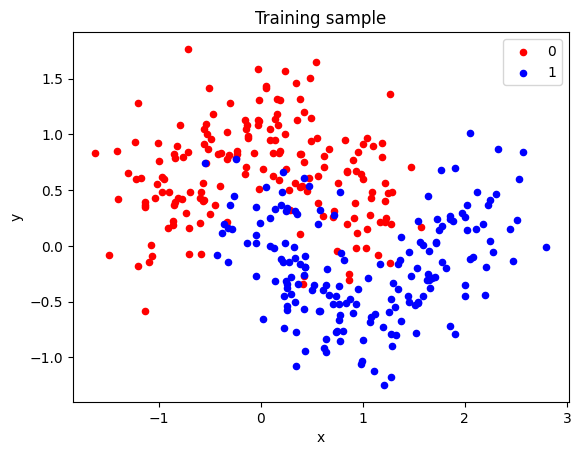

In [29]:
# scatter plot, dots colored by class value
df = pd.DataFrame(dict(x=X_train[:,0], y=X_train[:,1], label=y_train))
colors = {0:'red', 1:'blue'}
fig, ax = plt.subplots()
grouped = df.groupby('label')
for key, group in grouped:
    group.plot(ax=ax, kind='scatter', x='x', y='y', label=key, color=colors[key])
plt.title('Training sample')
plt.show()


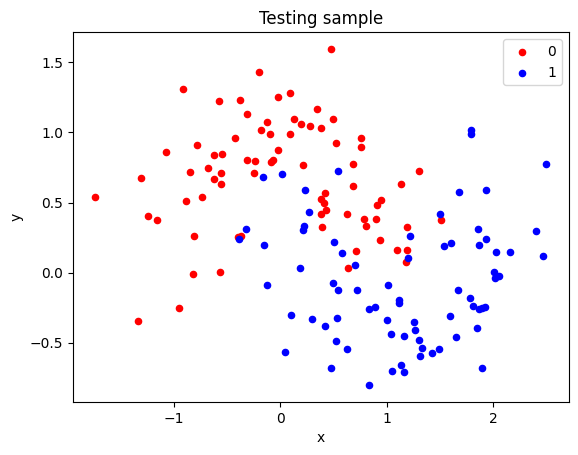

In [30]:
# scatter plot, dots colored by class value
df = pd.DataFrame(dict(x=X_test[:,0], y=X_test[:,1], label=y_test))
colors = {0:'red', 1:'blue'}
fig, ax = plt.subplots()
grouped = df.groupby('label')
for key, group in grouped:
    group.plot(ax=ax, kind='scatter', x='x', y='y', label=key, color=colors[key])
plt.title('Testing sample')
plt.show()



### Voting

Build different "weak classifiers" with uncorrelated error and vote between them.

## ✍🏼 Exercise 2.1

Use classification methods (SVC, KNN, LogisticRegression) together with `DecisionTreeClassifier` and write your own ensemble method with hard voting. Compare it with `VotingClassifier(voting='hard')` and with the soft voting below.

In [31]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
lr_clf = LogisticRegression(solver="lbfgs")
lr_clf.fit(X_train, y_train)

accuracy_score(y_test, lr_clf.predict(X_test))

0.86

In [32]:
# SVM Classifier model
from sklearn.svm import SVC
svm_clf = SVC(probability=True, random_state=42)
svm_clf.fit(X_train, y_train)

accuracy_score(y_test, svm_clf.predict(X_test))

0.9066666666666666

In [33]:
# KNN Classifier model
from sklearn.neighbors import KNeighborsClassifier
knn_clf = KNeighborsClassifier(n_neighbors=2)
knn_clf.fit(X_train, y_train)

accuracy_score(y_test, knn_clf.predict(X_test))

0.8533333333333334

In [34]:
# Decision Tree model 1
dtc_clf = DecisionTreeClassifier(max_depth=3, random_state=42)
dtc_clf.fit(X_train, y_train)

accuracy_score(y_test, dtc_clf.predict(X_test))

0.8866666666666667

In [35]:
# Decision Tree model 2
dtc2_clf = DecisionTreeClassifier(max_depth=6, random_state=42)
dtc2_clf.fit(X_train, y_train)
accuracy_score(y_test, dtc2_clf.predict(X_test))

0.8666666666666667

In [36]:
from sklearn.ensemble import VotingClassifier
voting_clf = VotingClassifier(
    estimators=[('lr', lr_clf),
                ('svc', svm_clf),
                ('knn', knn_clf),
                ('dtc', dtc_clf),
                ('dtc2', dtc2_clf)
                ],
    voting='soft')
voting_clf.fit(X_train, y_train)

for clf in (lr_clf, knn_clf, svm_clf, dtc_clf, dtc2_clf,voting_clf):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    print(clf.__class__.__name__, accuracy_score(y_test, y_pred))

LogisticRegression 0.86
KNeighborsClassifier 0.8533333333333334
SVC 0.9066666666666666
DecisionTreeClassifier 0.8866666666666667
DecisionTreeClassifier 0.8666666666666667
VotingClassifier 0.92


## Bagging and Pasting

Bagging (Bootstrap aggregating) was proposed by Leo Breiman in 1994 to improve the classification by combining classifications of randomly generated training sets.
* Bagging is a special case of the ensemble models with the averaging approach.
* Bagging (sampling with replacement) is a technique for reducing the variance of a predictor.
* It produces a different data set for every model by sampling from the same empirical distribution given by the training data set.
* This ensemble of trees with different "initial conditions" is more robust to noise and outliers.
* It can dramatically reduce the variance of unstable methods (like trees), leading to improved prediction; however, the simple, interpretable structure of a single tree is lost.

* Pasting: sampling without replacement.

Let's build bootstrap and vote method by hand:

In [37]:
from sklearn.utils import resample
#Initialization
n_trees = 500     # Hyperparameter to tune
max_dep = 5       # Hyperparameter to tune
max_samples = 150 # Hyperparameter to tune
predictions_train = np.zeros((X_train.shape[0], n_trees))
predictions_test  = np.zeros((y_test.shape[0], n_trees))

# Used model
model = DecisionTreeClassifier(max_depth=max_dep) # we can try a variety of depths here

#Bootstrap
for i in range(n_trees):
    X_bs, y_bs = resample(X_train, y_train, replace=True, n_samples=max_samples, random_state=i)

    model.fit(X_bs, y_bs)
    predictions_train[:,i] = model.predict(X_train)
    predictions_test[:,i] = model.predict(X_test)


#Make Predictions Dataframe
columns = ["Bootstrap-Model_"+str(i+1) for i in range(n_trees)]
predictions_train = pd.DataFrame(predictions_train, columns=columns)
predictions_test = pd.DataFrame(predictions_test, columns=columns)



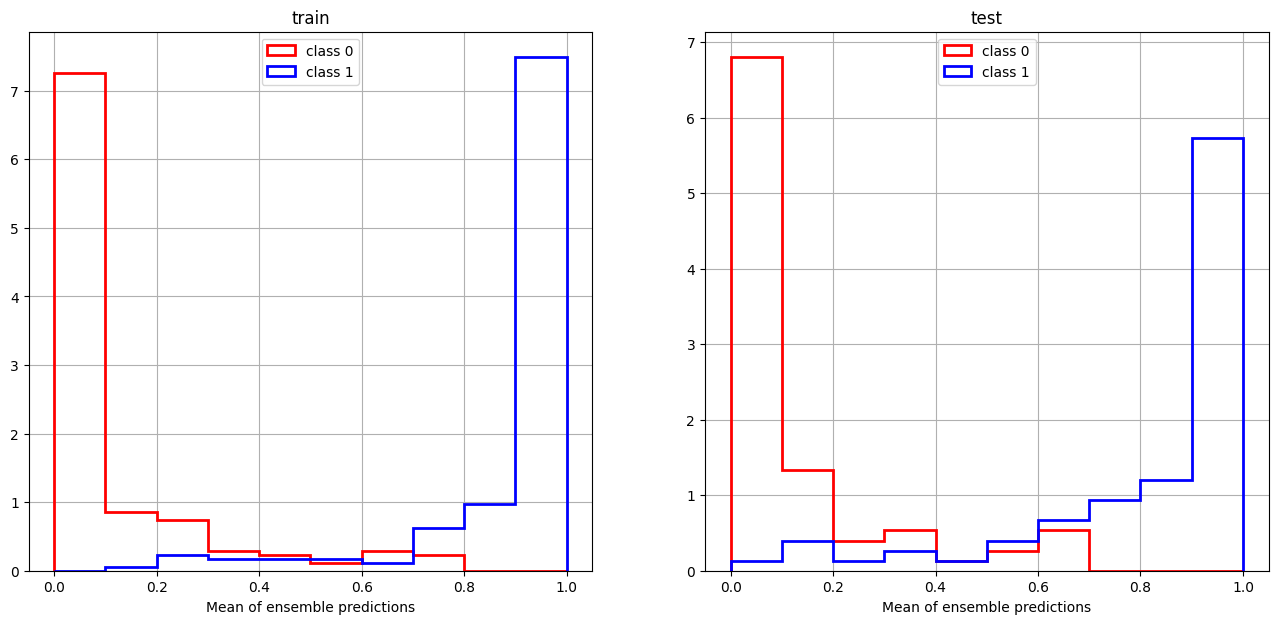

In [38]:
num_to_avg = 100 # we varied this line, from 1, 2, 3, 100, n_trees
fig, axs = plt.subplots(1, 2, figsize=(16, 7))
for (ax, label, predictions, y) in [
    (axs[0], 'train', predictions_train, y_train),
    (axs[1], 'test', predictions_test, y_test)
]:
    mean_predictions = predictions.iloc[:,:num_to_avg].mean(axis=1)
    mean_predictions[y == 0].hist(density=True, histtype='step', range=[0,1], label='class 0', lw=2, ax=ax, color="red")
    mean_predictions[y == 1].hist(density=True, histtype='step', range=[0,1], label='class 1', lw=2, ax=ax, color="blue")
    ax.legend(loc='upper center');
    ax.set_xlabel("Mean of ensemble predictions")
    ax.set_title(label)

Final hard voting ensemble model:

In [39]:
# Function to ensemble the prediction of each bagged decision tree model
def get_prediction(df, count=-1):
    """Average soft predictions from `df` and return hard labels (> 0.5)."""
    if count == -1:
        count = df.shape[1]
    count = max(1, min(count, df.shape[1]))
    averaged = df.iloc[:, :count].mean(axis=1)
    return averaged > 0.5

# Accuracy on the training and the test set
print('Accuracy, Training Set :', f"{100 * accuracy_score(y_train, get_prediction(predictions_train, count=-1))}%")
print('Accuracy, Testing Set :', f"{100 * accuracy_score(y_test, get_prediction(predictions_test, count=-1))}%")


Accuracy, Training Set : 94.0%
Accuracy, Testing Set : 90.66666666666666%


Use scikit-learn function `BaggingClassifier`

In [40]:
from sklearn.ensemble import BaggingClassifier

bag_clf = BaggingClassifier(
    DecisionTreeClassifier(), n_estimators=500,
    max_samples=100, bootstrap=True, n_jobs = -1, random_state=42)
bag_clf.fit(X_train, y_train)
y_pred = bag_clf.predict(X_test)

# Accuracy on the training and the test set
print("Accuracy, Training Set :", str(100*accuracy_score(y_train, bag_clf.predict(X_train)))+'%')
print("Accuracy, Testing Set :", str(100*accuracy_score(y_test, bag_clf.predict(X_test)))+'%')

Accuracy, Training Set : 94.0%
Accuracy, Testing Set : 92.0%


In [41]:
tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X_train, y_train)
y_pred_tree = tree_clf.predict(X_test)
print(accuracy_score(y_test, y_pred_tree))

0.8533333333333334


**Bagging produces smoother decision boundaries than trees.**

In [42]:
X, y =  make_circles(n_samples=300, shuffle=True, noise=0.15, random_state=0, factor=0.8)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

bag_clf = BaggingClassifier(
    DecisionTreeClassifier(), n_estimators=200,
    max_samples=50, bootstrap=True, n_jobs = -1, random_state=42)
bag_clf.fit(X_train, y_train)

tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [43]:
def plot_decision_boundary(clf, X, y, axes=(-1.5, 1.5, -1.5, 1.5), alpha=0.5, contour=True):
    """Visualise the classification regions learned by `clf` on a 2D dataset."""
    x1s = np.linspace(axes[0], axes[1], 100)
    x2s = np.linspace(axes[2], axes[3], 100)
    x1, x2 = np.meshgrid(x1s, x2s)
    grid = np.c_[x1.ravel(), x2.ravel()]
    y_pred = clf.predict(grid).reshape(x1.shape)
    decision_cmap = ListedColormap(['#fafab0', '#9898ff', '#a0faa0'])
    plt.contourf(x1, x2, y_pred, alpha=0.3, cmap=decision_cmap)
    if contour:
        boundary_cmap = ListedColormap(['#7d7d58', '#4c4c7f', '#507d50'])
        plt.contour(x1, x2, y_pred, cmap=boundary_cmap, alpha=0.8)
    plt.plot(X[:, 0][y == 0], X[:, 1][y == 0], 'yo', alpha=alpha)
    plt.plot(X[:, 0][y == 1], X[:, 1][y == 1], 'bs', alpha=alpha)
    plt.axis(axes)
    plt.xlabel(r"$x_1$", fontsize=18)
    plt.ylabel(r"$x_2$", fontsize=18, rotation=0)


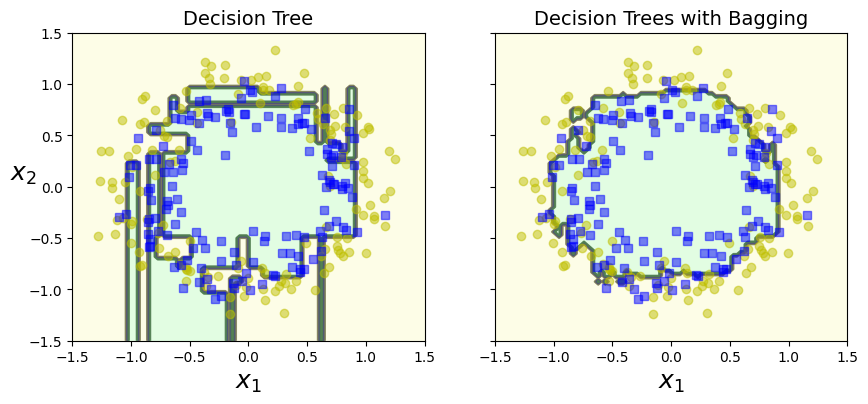

In [44]:
fix, axes = plt.subplots(ncols=2, figsize=(10,4), sharey=True)
plt.sca(axes[0])
plot_decision_boundary(tree_clf, X, y)
plt.title("Decision Tree", fontsize=14)
plt.sca(axes[1])
plot_decision_boundary(bag_clf, X, y)
plt.title("Decision Trees with Bagging", fontsize=14)
plt.ylabel("")
plt.show()

**OOB: out of bag samples:**  
In bagging procedure, some observations are sampled several times, while others may not be sampled at all.

If max_samples is equal to the size of the training set, only about 63 % of the instances are sampled on average for each predictor, the remaining instances are called out-of-bag.

Evaluation of the ensemble can be computed by averaging out the oob evaluations of each predictor.

In [45]:
bag_clf = BaggingClassifier(
    DecisionTreeClassifier(), n_estimators=500,
    bootstrap=True, oob_score=True, random_state=40)
bag_clf.fit(X_train, y_train)
print(bag_clf.oob_score_)
accuracy_score(y_train, bag_clf.predict(X_train))

0.6833333333333333


1.0

In [46]:
y_pred = bag_clf.predict(X_test)
accuracy_score(y_test, y_pred)

0.5833333333333334

## Random Forest

* Bagging of decision trees with an extra source of randomness: at each split only a random subset of features (`max_features`) is considered.
* The trees are therefore decorrelated, and averaging them reduces the variance more than plain bagging.
* Robust default for tabular data, little tuning needed, OOB error for free.

**Extra Trees** (Extremely Randomized Trees) go one step further: the split thresholds are drawn at random instead of being optimised. Even lower variance and faster training, sometimes slightly higher bias.

In [47]:
rnd_clf = RandomForestClassifier(n_estimators=500, max_leaf_nodes=16, random_state=42)
rnd_clf.fit(X_train, y_train)
y_pred_rf = rnd_clf.predict(X_test)

bag_clf = BaggingClassifier(
    DecisionTreeClassifier(max_features="sqrt", max_leaf_nodes=16),
    n_estimators=500, random_state=42)
bag_clf.fit(X_train, y_train)
y_pred = bag_clf.predict(X_test)

print(np.sum(y_pred == y_pred_rf) / len(y_pred))
print(accuracy_score(y_test, y_pred_rf))
print(accuracy_score(y_test, y_pred))

0.9833333333333333
0.5833333333333334
0.5666666666666667


In [48]:
from sklearn.ensemble import ExtraTreesClassifier

ext_clf = ExtraTreesClassifier(n_estimators=500, max_leaf_nodes=16, n_jobs=-1, random_state=42)
ext_clf.fit(X_train, y_train)
print("Random forest:", accuracy_score(y_test, y_pred_rf))
print("Extra trees:  ", accuracy_score(y_test, ext_clf.predict(X_test)))

Random forest: 0.5833333333333334
Extra trees:   0.5666666666666667


# Boosted Trees

Another way of building an ensemble model is to create a sequence of weak models, where later models correct the mistakes of the earlier ones.

Higher computational cost and harder to parallelise than bagging (the models are built sequentially), but with today's resources and histogram-based implementations this is rarely a problem.

## Adaptive boosting aka AdaBoost

AdaBoost adds predictors to the ensemble one by one, each focusing on the instances its predecessors got wrong. Since the ensemble is built step by step, it cannot be parallelised.
The AdaBoost algorithm was formulated by Yoav Freund and Robert Schapire in 1996.


Algorithm:
Each instance weight $w^{(i)}$ is initially set to $\frac{1}{m}$. The first predictor is trained and its weighted error rate $r_1$ is computed:
$$r_j = \frac{\sum_{i=1 , \hat{y}_j^{(i)} \neq y^{(i)}}^{m} w^{(i)}}{\sum_{i=1}^m w^{(i)}},$$
where $\hat{y}_j^{(i)}$ is the $j^{th}$ predictor's prediction for the $i^{th}$ observation.
The predictor weight $\alpha_j$ is computed in the next step by
$$\alpha_j = \eta \log \frac{1-r_j}{r_j},$$
where $\eta$ is the learning rate hyperparameter. Next the instance weights are updated for $i = 1,2, \ldots, m$:
$$w^{(i)} \leftarrow w^{(i)} \ \ \text{if} \ \ \hat{y}_j^{(i)} = y^{(i)}$$ and
$$w^{(i)} \leftarrow w^{(i)} e^{\alpha_j} \ \ \text{if} \ \ \hat{y}_j^{(i)} \neq y^{(i)}.$$
All the instance weights are normalized by $\sum_{i=1}^m w^{(i)}$. Finally,
a new predictor is trained using the updated weights and the whole process is repeated.

To make predictions, AdaBoost computes the predictions of all predictors and weights them using the predictor weights $\alpha_j$
$$\hat{y}(X) = \text{argmax}_k \sum_{j=1, \hat{y}_j(X) = k}^N \alpha_j .$$

Scikit-learn implements the multiclass version SAMME (Stagewise Additive Modeling using a Multiclass Exponential loss function); for $K > 2$ classes the predictor weight gets an extra term $\log(K-1)$. (Older versions defaulted to the variant SAMME.R that used predicted probabilities; it was deprecated in scikit-learn 1.4 and removed in 1.6.) For regression there is `AdaBoostRegressor` (AdaBoost.R2).


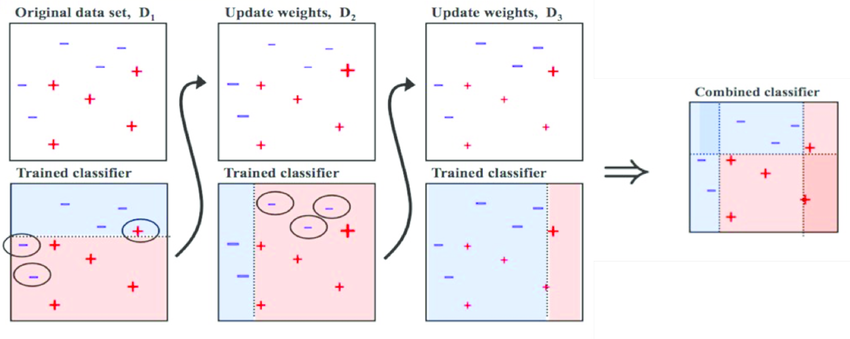


Source: https://www.researchgate.net/publication/306054843_Multivariate_Analysis_of_the_Vector_Boson_Fusion_Higgs_Boson

In [49]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Training AdaBoost model with DecisionTreeClassifier as the base estimator
model = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=2, max_leaf_nodes=20),
                           n_estimators=25,
                           learning_rate=0.05,
                           random_state=42)
model.fit(X_train, y_train)

# Training a second AdaBoost model with different parameters
model2 = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3),
                            n_estimators=50,
                            learning_rate=0.2,
                            random_state=42)
model2.fit(X_train, y_train)

# Predict on training and testing sets
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# Performance evaluation
train_score = accuracy_score(y_train, y_pred_train) * 100
test_score = accuracy_score(y_test, y_pred_test) * 100

# Display results
print("Accuracy, Training Set :", str(train_score) + '%')
print("Accuracy, Testing Set :", str(test_score) + '%')
print("Accuracy model2, Testing Set  :", str(accuracy_score(y_test, model2.predict(X_test)) * 100) + '%')


Accuracy, Training Set :

 64.16666666666667%
Accuracy, Testing Set : 45.0%
Accuracy model2, Testing Set  : 61.66666666666667%


In [50]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt


pipeline = Pipeline([
    ('adaboost', AdaBoostClassifier(estimator=DecisionTreeClassifier()))])

# Define parameter grid for hyperparameter tuning using GridSearchCV
param_grid = {
    'adaboost__estimator__max_depth': [2, 3, 4],
    'adaboost__estimator__min_samples_split': [4, 6, 10],
    'adaboost__n_estimators': [20, 30 ,50],
    'adaboost__learning_rate': [0.01, 0.1]
}

# Initialize GridSearchCV to find the best parameters
grid_search = GridSearchCV(estimator=pipeline, param_grid=param_grid, cv=5, scoring='accuracy')

# Fit the model with hyperparameter tuning
grid_search.fit(X_train, y_train)

# Get the best model from GridSearchCV
best_model = grid_search.best_estimator_


In [51]:
# Predict on training and test sets
y_pred_train = best_model.predict(X_train)
y_pred_test = best_model.predict(X_test)

# Performance evaluation
train_score = accuracy_score(y_train, y_pred_train) * 100
test_score = accuracy_score(y_test, y_pred_test) * 100

# Output model accuracy and best hyperparameters
print("Best hyperparameters:", grid_search.best_params_)
print("Accuracy, Training Set:", str(train_score) + '%')
print("Accuracy, Testing Set:", str(test_score) + '%')

Best hyperparameters: {'adaboost__estimator__max_depth': 4, 'adaboost__estimator__min_samples_split': 10, 'adaboost__learning_rate': 0.1, 'adaboost__n_estimators': 20}
Accuracy, Training Set: 77.91666666666667%
Accuracy, Testing Set: 55.00000000000001%


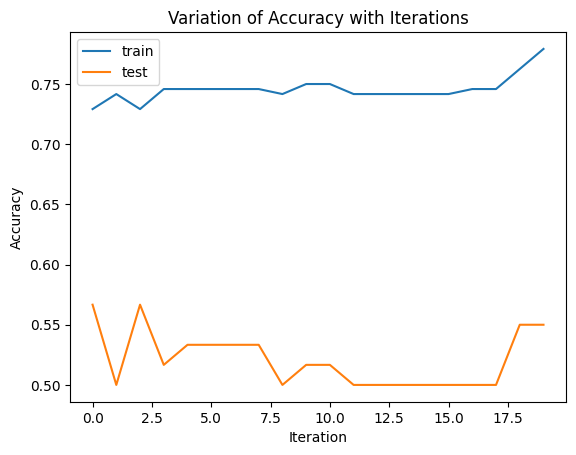

In [52]:
# Access the AdaBoostClassifier inside the pipeline
best_adaboost_model = best_model.named_steps['adaboost']

# Plot training and test scores during boosting iterations
train_scores = list(best_adaboost_model.staged_score(X_train, y_train))
test_scores = list(best_adaboost_model.staged_score(X_test, y_test))

# Plot the results
plt.plot(train_scores, label='train')
plt.plot(test_scores, label='test')
plt.xlabel('Iteration')
plt.ylabel('Accuracy')
plt.title("Variation of Accuracy with Iterations")
plt.legend()
plt.show()


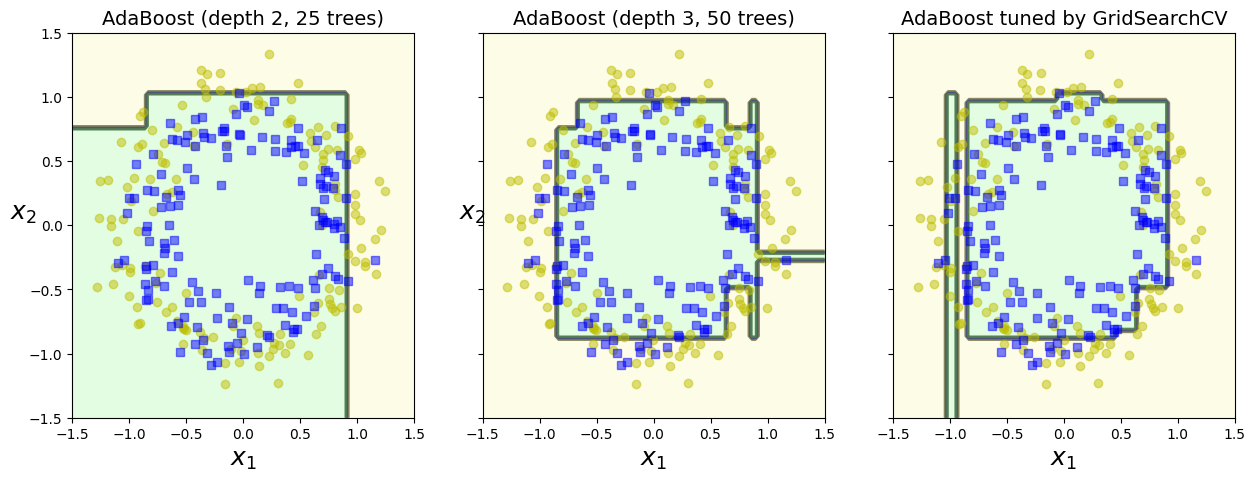

In [53]:
fix, axes = plt.subplots(ncols=3, figsize=(15,5), sharey=True)
plt.sca(axes[0])
plot_decision_boundary(model, X, y)
plt.title("AdaBoost (depth 2, 25 trees)", fontsize=14)
plt.sca(axes[1])
plot_decision_boundary(model2, X, y)
plt.title("AdaBoost (depth 3, 50 trees)", fontsize=14)
plt.sca(axes[2])
plot_decision_boundary(best_adaboost_model, X, y)
plt.title("AdaBoost tuned by GridSearchCV", fontsize=14)
plt.ylabel("")
plt.show()

Finally ;-)

## Gradient boosting

As all boosting methods, Gradient Boosted Decision Trees (GBDT) build the ensemble iteratively by correcting the errors of the previous step.

An ensemble of weak simple models $\{T_h\}_{h \in H}$ is additively combined into a single strong and more complex model.

Each model $T_h$ might have a poor fit on the data, but a linear combination
of the ensemble
$$T = \sum_{h} \lambda_h T_h $$
is flexible and it can produce very good results.

1. Fit a simple model $T^{(0)}$ on the training data $(x_1 , y_1), \ldots, (x_N , y_N )$, set $T^{(0)} \to T$ and compute the residuals $r_1 , \ldots, r_N$ of $T$.
2. Fit a model $T^{(1)}$ to the current residuals, i.e. train it using
$(x_1,r_1) , \ldots, (x_N,r_N)$.
3. Set $T + \lambda T^{(1)} \to T$.
4. Update the residuals $r_n - \lambda T^{(1)}(x_n) \to r_n$, $n = 1, \ldots , N$, where $\lambda$ is a constant called the learning rate (step size).
5. Repeat steps 2-4 until a stopping condition is met.

With learning rate $\lambda = 1$ we obtain a low bias but high variance model!

Why does the algorithm converge?

Each simple model $T^{(i)}$ added to the ensemble $T$ models the errors of $T$. With each addition of $T^{(i)}$ the residuals are reduced to $r_n - \lambda T^{(i)} (x_n)$.

Since $MSE(\hat{y}_1, \ldots, \hat{y}_N) = \frac{1}{N} \sum_{n=1}^N (\hat{y}_n - {y}_n)^2$, its gradient is $\frac{\partial MSE}{\partial \hat{y}_n} = -\frac{2}{N} r_n$, so the residuals are (up to a constant) the negative gradient and the update $\hat{y}_n + \lambda r_n \to \hat{y}_n$ is a step of gradient descent.

For a general differentiable loss, the trees are fitted to the negative gradient of the loss (the "pseudo-residuals") – hence the name gradient boosting. The learning rate $\lambda$ plays the role of the step size of the gradient descent.

Let's use again function from  O'Reilly book Hands-on Machine Learning with Scikit-Learn, Keras and TensorFlow: https://github.com/ageron/handson-ml3


In [54]:
# Let create a simple quadratic dataset:
np.random.seed(42)
X = np.random.rand(100, 1) - 0.5
y = 3*X[:, 0]**2 + 0.05 * np.random.randn(100)

Now let's train a decision tree regressor on this dataset:

In [55]:
tree_reg1 = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_reg1.fit(X, y)

,criterion,'squared_error'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [56]:
y2 = y - tree_reg1.predict(X)
tree_reg2 = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_reg2.fit(X, y2)

,criterion,'squared_error'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [57]:
y3 = y2 - tree_reg2.predict(X)
tree_reg3 = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_reg3.fit(X, y3)

,criterion,'squared_error'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [58]:
X_new = np.array([[0.8]])

In [59]:
y_pred = sum(tree.predict(X_new) for tree in (tree_reg1, tree_reg2, tree_reg3))

In [60]:
y_pred

array([0.75026781])

The first predictor (top left) is trained normally, then each consecutive predictor (middle left and lower left) is trained on the previous predictor’s residuals; the right column shows the resulting ensemble’s predictions:

In [61]:
def plot_predictions(regressors, X, y, axes, label=None, style='r-', data_style='b.', data_label=None):
    """Plot cumulative predictions from sequential regressors (e.g. boosting steps)."""
    x1 = np.linspace(axes[0], axes[1], 500)
    y_pred = sum(regressor.predict(x1.reshape(-1, 1)) for regressor in regressors)
    plt.plot(X[:, 0], y, data_style, label=data_label)
    plt.plot(x1, y_pred, style, linewidth=2, label=label)
    if label or data_label:
        plt.legend(loc='upper center', fontsize=16)
    plt.axis(axes)


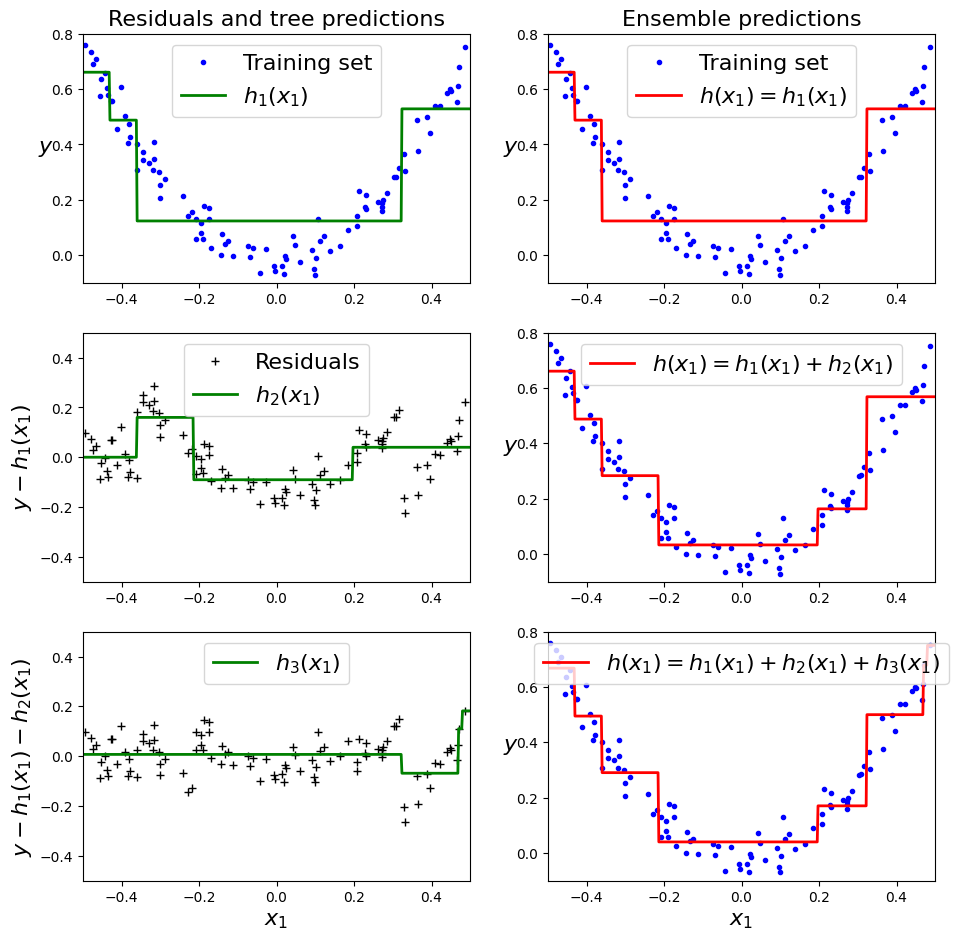

In [62]:
plt.figure(figsize=(11,11))

plt.subplot(321)
plot_predictions([tree_reg1], X, y, axes=[-0.5, 0.5, -0.1, 0.8], label="$h_1(x_1)$", style="g-", data_label="Training set")
plt.ylabel("$y$", fontsize=16, rotation=0)
plt.title("Residuals and tree predictions", fontsize=16)

plt.subplot(322)
plot_predictions([tree_reg1], X, y, axes=[-0.5, 0.5, -0.1, 0.8], label="$h(x_1) = h_1(x_1)$", data_label="Training set")
plt.ylabel("$y$", fontsize=16, rotation=0)
plt.title("Ensemble predictions", fontsize=16)

plt.subplot(323)
plot_predictions([tree_reg2], X, y2, axes=[-0.5, 0.5, -0.5, 0.5], label="$h_2(x_1)$", style="g-", data_style="k+", data_label="Residuals")
plt.ylabel("$y - h_1(x_1)$", fontsize=16)

plt.subplot(324)
plot_predictions([tree_reg1, tree_reg2], X, y, axes=[-0.5, 0.5, -0.1, 0.8], label="$h(x_1) = h_1(x_1) + h_2(x_1)$")
plt.ylabel("$y$", fontsize=16, rotation=0)

plt.subplot(325)
plot_predictions([tree_reg3], X, y3, axes=[-0.5, 0.5, -0.5, 0.5], label="$h_3(x_1)$", style="g-", data_style="k+")
plt.ylabel("$y - h_1(x_1) - h_2(x_1)$", fontsize=16)
plt.xlabel("$x_1$", fontsize=16)

plt.subplot(326)
plot_predictions([tree_reg1, tree_reg2, tree_reg3], X, y, axes=[-0.5, 0.5, -0.1, 0.8], label="$h(x_1) = h_1(x_1) + h_2(x_1) + h_3(x_1)$")
plt.xlabel("$x_1$", fontsize=16)
plt.ylabel("$y$", fontsize=16, rotation=0)
plt.show()

Now let's try a gradient boosting regressor:

In [63]:
from sklearn.ensemble import GradientBoostingRegressor

gbrt = GradientBoostingRegressor(max_depth=2, n_estimators=3, learning_rate=1.0, random_state=42)
gbrt.fit(X, y)

,loss,'squared_error'
,learning_rate,1.0
,n_estimators,3
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,2
,min_impurity_decrease,0.0
,init,None


In [64]:
gbrt_slow = GradientBoostingRegressor(max_depth=2, n_estimators=200, learning_rate=0.1, random_state=42)
gbrt_slow.fit(X, y)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,200
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,2
,min_impurity_decrease,0.0
,init,None


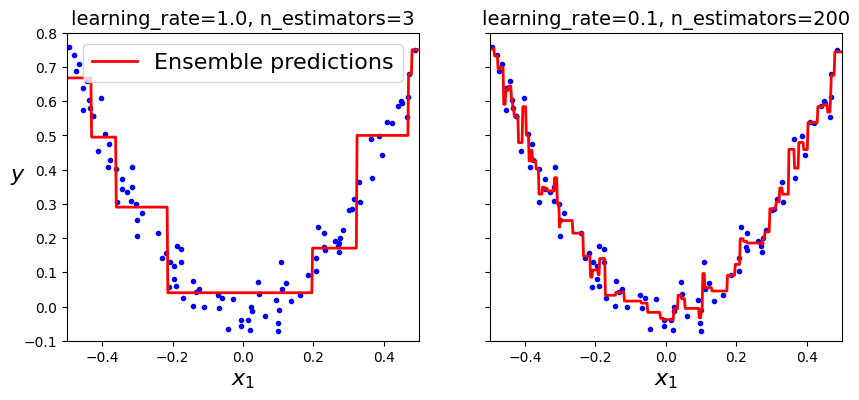

In [65]:
fix, axes = plt.subplots(ncols=2, figsize=(10,4), sharey=True)

plt.sca(axes[0])
plot_predictions([gbrt], X, y, axes=[-0.5, 0.5, -0.1, 0.8], label="Ensemble predictions")
plt.title("learning_rate={}, n_estimators={}".format(gbrt.learning_rate, gbrt.n_estimators), fontsize=14)
plt.xlabel("$x_1$", fontsize=16)
plt.ylabel("$y$", fontsize=16, rotation=0)

plt.sca(axes[1])
plot_predictions([gbrt_slow], X, y, axes=[-0.5, 0.5, -0.1, 0.8])
plt.title("learning_rate={}, n_estimators={}".format(gbrt_slow.learning_rate, gbrt_slow.n_estimators), fontsize=14)
plt.xlabel("$x_1$", fontsize=16)
plt.show()

Question: Which model do you prefere and why?

**Gradient Boosting with Early stopping:**

In [66]:
X_train, X_val, y_train, y_val = train_test_split(X, y, random_state=49)

gbrt = GradientBoostingRegressor(max_depth=2, n_estimators=120, random_state=42)
gbrt.fit(X_train, y_train)

errors = [mean_squared_error(y_val, y_pred)
          for y_pred in gbrt.staged_predict(X_val)]
bst_n_estimators = np.argmin(errors) + 1

gbrt_best = GradientBoostingRegressor(max_depth=2, n_estimators=bst_n_estimators, random_state=42)
gbrt_best.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,56
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,2
,min_impurity_decrease,0.0
,init,None


 Tuning the number of trees using early stopping:

In [67]:
min_error = np.min(errors)

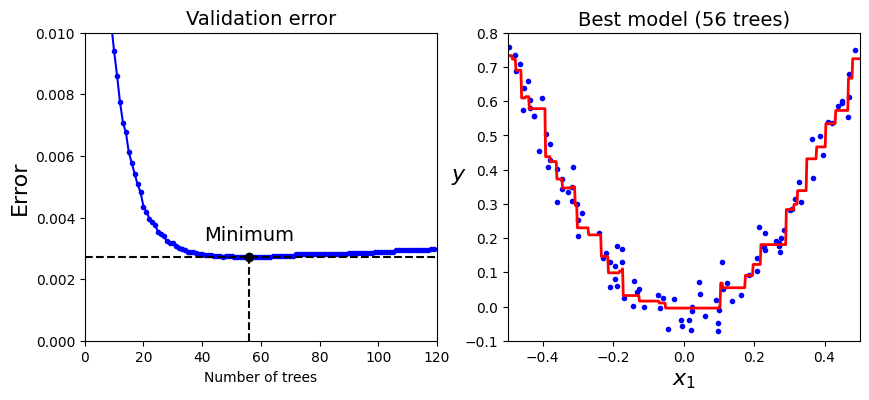

In [68]:
plt.figure(figsize=(10, 4))

plt.subplot(121)
plt.plot(errors, "b.-")
plt.plot([bst_n_estimators, bst_n_estimators], [0, min_error], "k--")
plt.plot([0, 120], [min_error, min_error], "k--")
plt.plot(bst_n_estimators, min_error, "ko")
plt.text(bst_n_estimators, min_error*1.2, "Minimum", ha="center", fontsize=14)
plt.axis([0, 120, 0, 0.01])
plt.xlabel("Number of trees")
plt.ylabel("Error", fontsize=16)
plt.title("Validation error", fontsize=14)

plt.subplot(122)
plot_predictions([gbrt_best], X, y, axes=[-0.5, 0.5, -0.1, 0.8])
plt.title("Best model (%d trees)" % bst_n_estimators, fontsize=14)
plt.ylabel("$y$", fontsize=16, rotation=0)
plt.xlabel("$x_1$", fontsize=16)

plt.show()

Early stopping with some patience (interrupts training only after there's no improvement for 5 iterations):

In [69]:
gbrt = GradientBoostingRegressor(max_depth=2, warm_start=True, random_state=42)

min_val_error = float("inf")
error_going_up = 0
for n_estimators in range(1, 120):
    gbrt.n_estimators = n_estimators
    gbrt.fit(X_train, y_train)
    y_pred = gbrt.predict(X_val)
    val_error = mean_squared_error(y_val, y_pred)
    if val_error < min_val_error:
        min_val_error = val_error
        error_going_up = 0
    else:
        error_going_up += 1
        if error_going_up == 5:
            break  # early stopping

In [70]:
print(gbrt.n_estimators)

61


In [71]:
print("Minimum validation MSE:", min_val_error)

Minimum validation MSE: 0.002712853325235463


In current libraries you do not write these loops yourself – the loops above only show what happens inside:
* `GradientBoostingRegressor(n_iter_no_change=..., validation_fraction=...)` and `HistGradientBoostingRegressor(early_stopping=True)` hold out a validation part of the training data internally,
* XGBoost, LightGBM and CatBoost use `early_stopping_rounds` together with an explicit `eval_set`.

In [72]:
from sklearn.ensemble import HistGradientBoostingRegressor

gbrt_es = GradientBoostingRegressor(max_depth=2, n_estimators=500, learning_rate=0.1,
                                    n_iter_no_change=5, validation_fraction=0.2, random_state=42)
gbrt_es.fit(X_train, y_train)
print("GradientBoostingRegressor, trees actually fitted:", gbrt_es.n_estimators_)

hgb = HistGradientBoostingRegressor(max_depth=2, max_iter=500, early_stopping=True, validation_fraction=0.2,
                                    n_iter_no_change=5, min_samples_leaf=5, random_state=42)
hgb.fit(X_train, y_train)
print("HistGradientBoostingRegressor, iterations:", hgb.n_iter_)

GradientBoostingRegressor, trees actually fitted: 54


HistGradientBoostingRegressor, iterations: 70


### Modern gradient boosting libraries
`GradientBoostingRegressor` is the textbook implementation. For real tabular data, use the histogram-based implementations: scikit-learn `HistGradientBoostingRegressor` (native missing values and categorical features), **XGBoost**, **LightGBM** and **CatBoost**. They bin the features into histograms (fast on large data), add regularisation (L1/L2 penalties, minimum child weight, row and column subsampling) and support early stopping. LightGBM grows trees leaf-wise, CatBoost builds symmetric trees and encodes categorical features natively with ordered target statistics. A tuned comparison of the three libraries is in the last section of this notebook.

## Stacking

Stacking is based on a simple idea: instead of using a trivial function, such as hard voting, to aggregate the predictions of the base models, we train another model (the meta-model or *blender*) to perform the aggregation.

The meta-model must be trained on **out-of-fold predictions** of the base models (another use of k-fold CV); otherwise it learns from predictions on data the base models have already seen. `StackingClassifier` / `StackingRegressor` do this for you (`cv=5`).

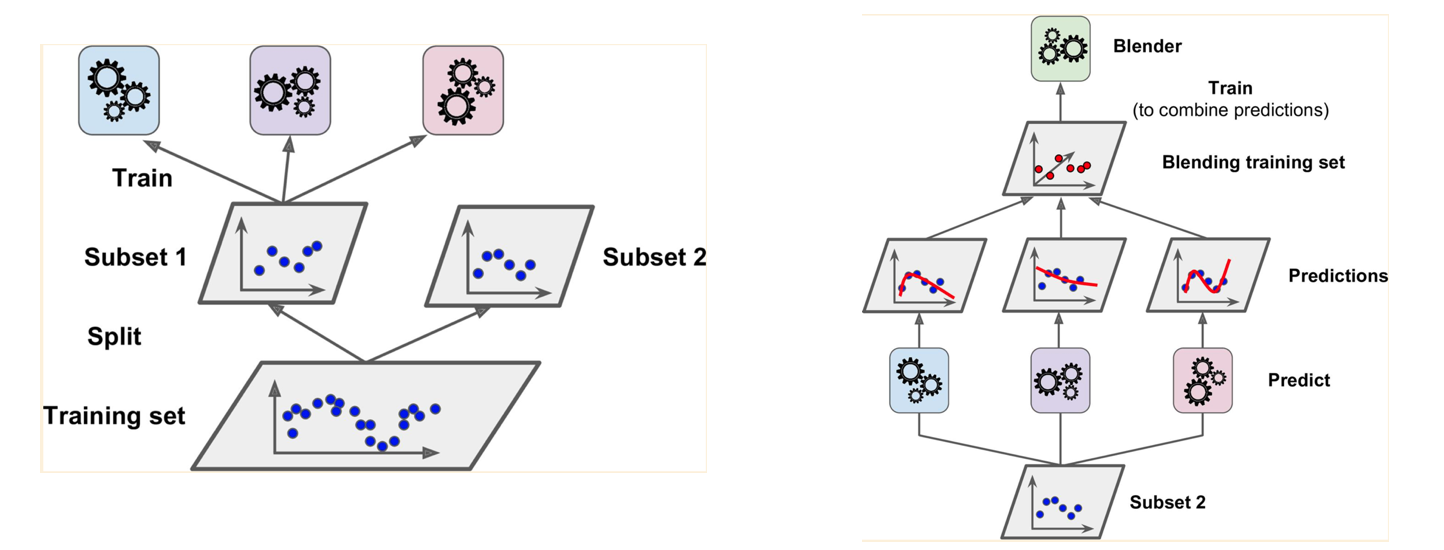

In [73]:
from sklearn.ensemble import StackingClassifier

# Back to the moons classification data
X_moons, y_moons = make_moons(n_samples=500, noise=0.30, random_state=42)
Xm_train, Xm_test, ym_train, ym_test = train_test_split(X_moons, y_moons, test_size=0.3, random_state=42)

stack_clf = StackingClassifier(
    estimators=[
        ("lr", LogisticRegression()),
        ("svc", SVC(probability=True, random_state=42)),
        ("rf", RandomForestClassifier(n_estimators=200, random_state=42)),
    ],
    final_estimator=LogisticRegression(),
    cv=5,
)
stack_clf.fit(Xm_train, ym_train)
for name, est in stack_clf.named_estimators_.items():
    print(f"{name:10s} accuracy: {accuracy_score(ym_test, est.predict(Xm_test)):.3f}")
print(f"stacking   accuracy: {accuracy_score(ym_test, stack_clf.predict(Xm_test)):.3f}")

lr         accuracy: 0.860
svc        accuracy: 0.907
rf         accuracy: 0.900
stacking   accuracy: 0.933


## ✍🏼 Exercise 2.2

Questions:

* Compare advantages and disadvantages of regression decision trees vs. linear methods.
* Can we use decision tree methods for predicting time series?
* Can we use decision tree methods for image classification?
* When do we shuffle and when do we stratify the train/test split?
* Can scaling of the data set improve the performance of a decision tree method?
* Can some transformation improve the performance of a decision tree method?

# 3. Pipelines in Scikit-Learn

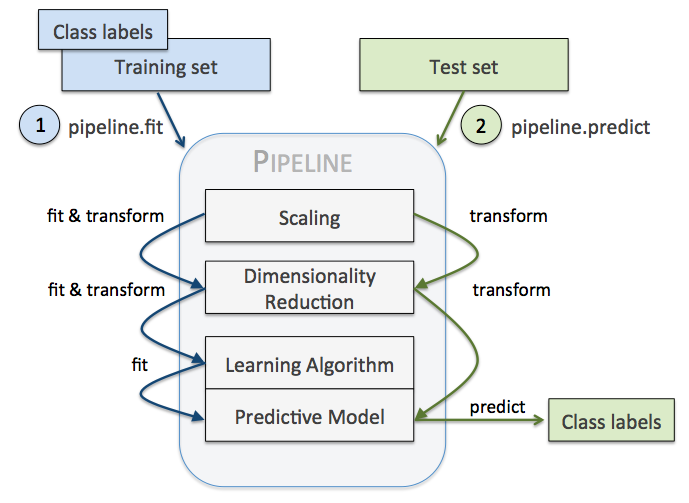

In [74]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn import preprocessing
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.compose import make_column_selector
from sklearn.feature_selection import SelectKBest
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

#from catboost import CatBoostRegressor, Pool


In [75]:
# Diabetes dataset (reals, regression)

# Load the example datasets
# https://scikit-learn.org/stable/datasets/toy_dataset.html#diabetes-dataset

from sklearn.datasets import load_diabetes

diabetes = load_diabetes()

X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
#y = pd.DataFrame(diabetes.target)
y = diabetes.target

X.info()
X.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
dtypes: float64(10)
memory usage: 34.7 KB


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01


In [76]:
# split the dataframe to train and test parts
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [77]:
# Gradient Boosting pipeline with robust preprocessing
from scipy.stats import randint, uniform, loguniform

numeric_selector = make_column_selector(dtype_include=np.number)
categorical_selector = make_column_selector(dtype_include=['object', 'category'])

# Trees are invariant to monotone scaling of the features; the scaler is here only to show the
# reusable pattern (it matters for linear models, kNN, SVM or neural networks)
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler()),
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

pipeline_preprocess = ColumnTransformer(
    transformers=[
        ('numerical_preprocessing', numeric_pipeline, numeric_selector),
        ('categorical_preprocessing', categorical_pipeline, categorical_selector),
    ],
    remainder='drop',
)

pipeline_preprocess.set_output(transform='pandas')

gb_pipeline = Pipeline([
    ('transform_inputs', pipeline_preprocess),
    ('reg', GradientBoostingRegressor(random_state=RANDOM_STATE)),
])

# The exhaustive GridSearchCV over 3^5 = 243 combinations x 5 folds was the classical approach;
# a random search finds comparably good models with a fraction of the fits
param_distributions = {
    'reg__n_estimators': randint(100, 600),
    'reg__max_depth': randint(2, 5),
    'reg__learning_rate': loguniform(0.01, 0.3),
    'reg__subsample': uniform(0.6, 0.4),
    'reg__max_features': [None, 'sqrt', 'log2'],
}

model = RandomizedSearchCV(
    estimator=gb_pipeline,
    param_distributions=param_distributions,
    n_iter=30,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=RANDOM_STATE,
).fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f"Model RMSE: {root_mean_squared_error(y_test, y_pred):.3f}")
print(f"Model MAE: {mean_absolute_error(y_test, y_pred):.3f}")
print(f"Model R2: {r2_score(y_test, y_pred):.3f}")
print(f"Best hyperparameters: {model.best_params_}")

Model RMSE: 52.575
Model MAE: 42.228
Model R2: 0.488
Best hyperparameters: {'reg__learning_rate': 0.013833507535062186, 'reg__max_depth': 4, 'reg__max_features': 'log2', 'reg__n_estimators': 161, 'reg__subsample': 0.7300733288106989}


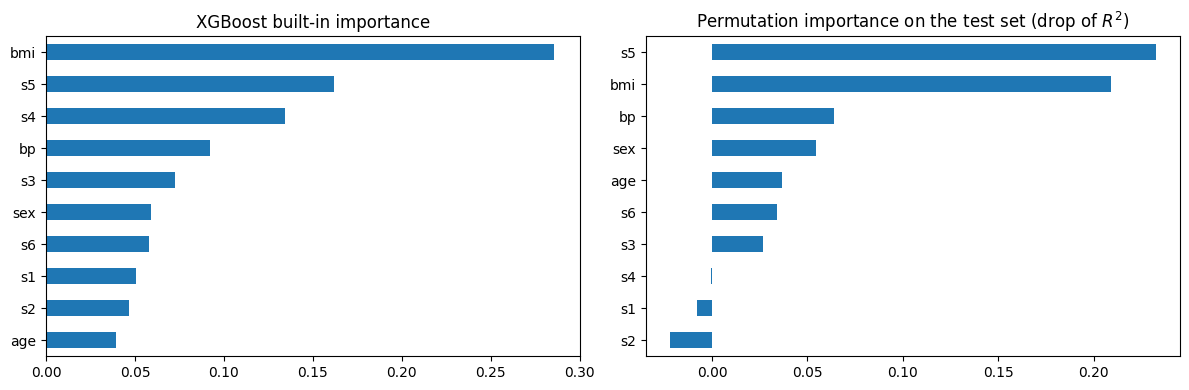

In [78]:
# Built-in feature importance vs. permutation importance
from xgboost import XGBRegressor
from sklearn.inspection import permutation_importance

xgb_model = XGBRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, random_state=RANDOM_STATE)
xgb_model.fit(X_train, y_train)  # fit on the training set only, never on the test set

builtin_imp = pd.Series(xgb_model.feature_importances_, index=X_train.columns).sort_values()
perm = permutation_importance(xgb_model, X_test, y_test, n_repeats=20, scoring='r2', random_state=RANDOM_STATE)
perm_imp = pd.Series(perm.importances_mean, index=X_test.columns).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
builtin_imp.plot.barh(ax=axes[0], title="XGBoost built-in importance")
perm_imp.plot.barh(ax=axes[1], title="Permutation importance on the test set (drop of $R^2$)")
plt.tight_layout()
plt.show()

#  ✍🏼 Final Exercise 3.1

* Use the diabetes data set from sklearn.
* Split it into a training and a test set; use cross-validation on the training set only.
* Train various regression methods: Random Forest, gradient boosted methods, ...
* Use CV and a grid or random search to optimize the hyperparameters of the selected methods.
* Try to combine your estimators into an ensemble that outperforms each individual predictor.
* Use the averaging and the blending (stacking) approach.

Inspiration: https://www.programcreek.com/python/example/85913/sklearn.datasets.load_diabetes

# 4. Interpretation of features

* https://christophm.github.io/interpretable-ml-book/

* https://shap.readthedocs.io/en/latest/

In [79]:
try:
    import shap
except ImportError:  # install only when missing
    %pip install -q shap
    import shap
import warnings
warnings.filterwarnings("ignore", message="The NumPy global RNG was seeded")  # internal shap warning
shap.initjs()  # JavaScript needed for the interactive force plots

In [80]:
rnd_reg = RandomForestRegressor(n_estimators=500, max_leaf_nodes=16, random_state=42)
rnd_reg.fit(X_train, y_train)

y_pred = rnd_reg.predict(X_test)
model_mse = mean_squared_error(y_test, y_pred)

print(f"Model mse: {model_mse} \n")


Model mse: 2765.1191854009317 



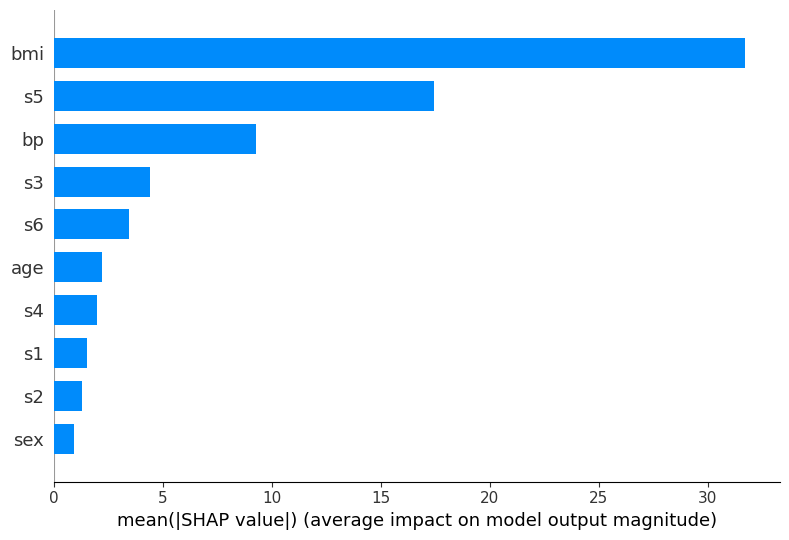

In [81]:
explainer = shap.TreeExplainer(rnd_reg)
shap_values = explainer.shap_values(X_train)
shap.summary_plot(shap_values, X_train, plot_type="bar")

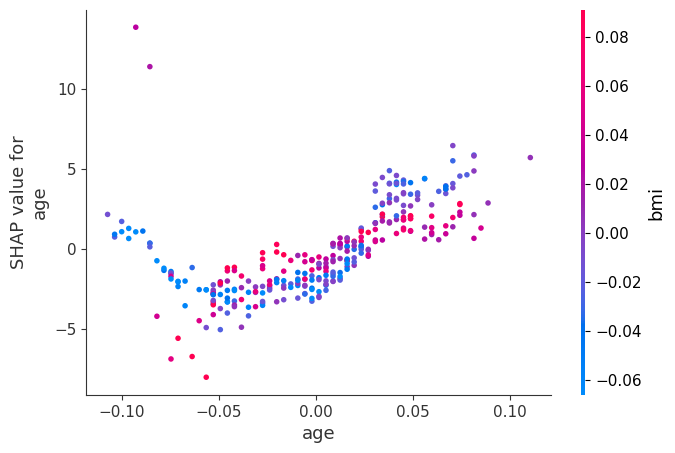

In [82]:
shap.dependence_plot("age", shap_values, X_train)

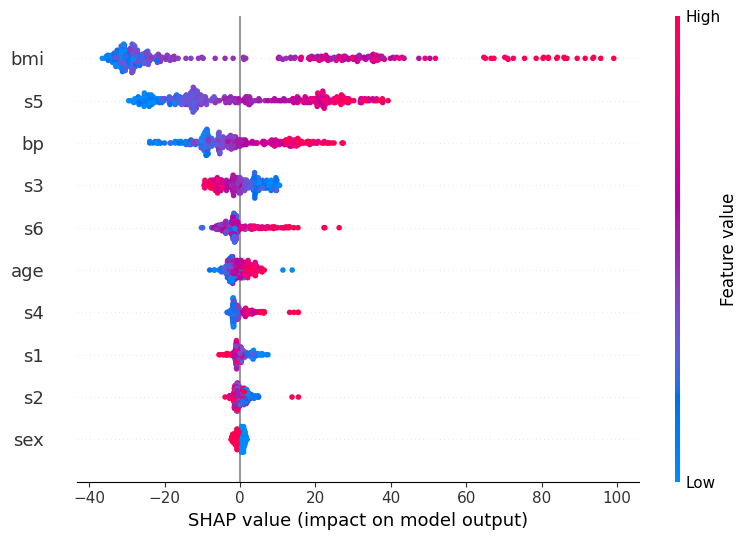

In [83]:
shap.summary_plot(shap_values, X_train)

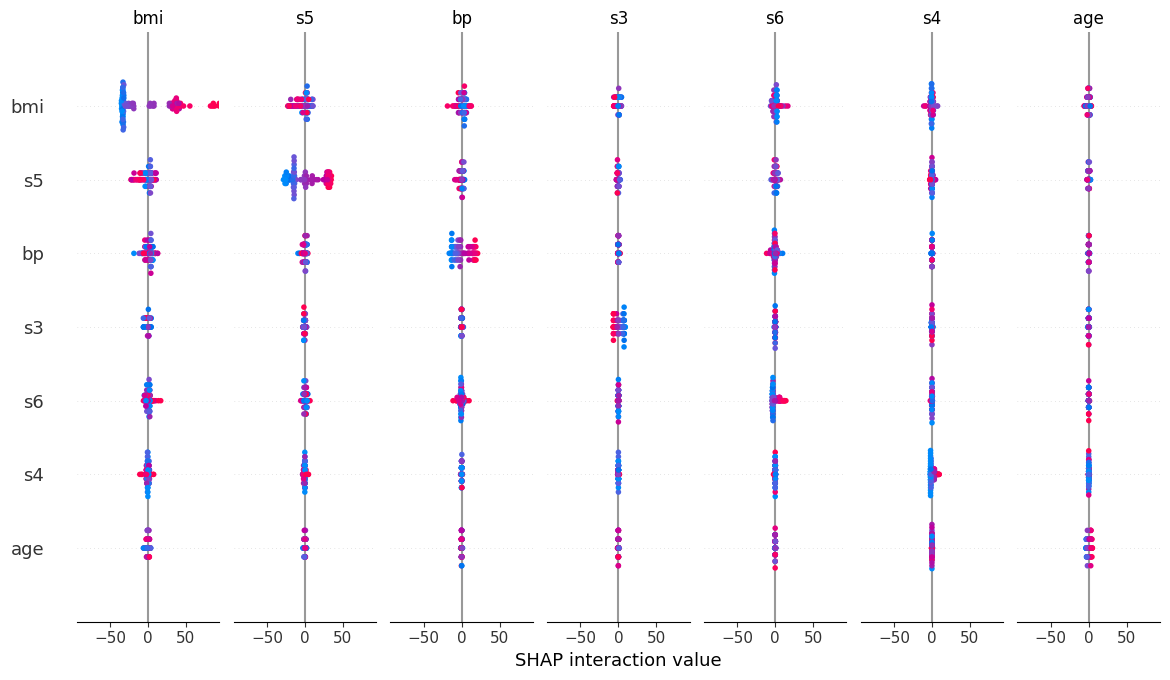

In [84]:
# Interaction values are expensive (number of features x more work), compute them on a subsample
shap_interaction_values = explainer.shap_interaction_values(X_train.iloc[:100])
shap.summary_plot(shap_interaction_values, X_train.iloc[:100])

In [85]:
# Write in a function
def shap_plot(index: int, model, samples):
    """Render a SHAP force plot for a single observation indexed by `index`."""
    explainer_model = shap.TreeExplainer(model)
    shap_values_model = explainer_model.shap_values(samples)
    return shap.force_plot(explainer_model.expected_value, shap_values_model[index], samples.iloc[[index]])


In [86]:
X_train.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
225,0.030811,0.050680,0.032595,0.049415,-0.040096,-0.043589,-0.069172,0.034309,0.063015,0.003064
412,0.074401,-0.044642,0.085408,0.063187,0.014942,0.013091,0.015505,-0.002592,0.006207,0.085907
118,-0.056370,0.050680,-0.010517,0.025315,0.023198,0.040022,-0.039719,0.034309,0.020609,0.056912
114,0.023546,-0.044642,0.110198,0.063187,0.013567,-0.032942,-0.024993,0.020655,0.099241,0.023775
364,0.001751,0.050680,-0.006206,-0.019442,-0.009825,0.004949,-0.039719,0.034309,0.014821,0.098333


Explanation of each observation:

In [87]:
shap.initjs() # Javascript need
shap_plot(0,rnd_reg,X_train)

# 5. Workflow with three tuned ensembles
Back to the California housing data with a production-ready preprocessing pipeline: compare baseline ensembles and tune XGBoost, LightGBM and CatBoost with Optuna (Bayesian optimisation of the cross-validated RMSE).

In [88]:
import importlib.util
import time

REQUIRED_PACKAGES = ['shap', 'xgboost', 'lightgbm', 'catboost', 'optuna']
missing = [p for p in REQUIRED_PACKAGES if importlib.util.find_spec(p) is None]
if missing:
    print('Installing missing packages:', missing)
    %pip install -q {' '.join(missing)}

import shap
import optuna

from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

optuna.logging.set_verbosity(optuna.logging.WARNING)

housing = fetch_california_housing(as_frame=True)
X = housing.data
y = housing.target

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
N_TRIALS = 15        # maximum number of Optuna trials per library, every trial = 5 model fits
TIME_BUDGET_S = 90   # ... but at most this many seconds per library (Colab has only 2 CPU cores)

In [89]:

def create_preprocessor() -> ColumnTransformer:
    """Return a ColumnTransformer with robust numeric scaling and safe categorical encoding."""
    numeric_selector = make_column_selector(dtype_include=np.number)
    categorical_selector = make_column_selector(dtype_include=['object', 'category'])

    numeric_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', RobustScaler()),
    ])

    categorical_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('numeric', numeric_pipeline, numeric_selector),
            ('categorical', categorical_pipeline, categorical_selector),
        ],
        remainder='drop',
    )
    preprocessor.set_output(transform='pandas')
    return preprocessor


def build_pipeline(regressor) -> Pipeline:
    return Pipeline([
        ('preprocess', create_preprocessor()),
        ('regressor', regressor),
    ])


def evaluate_models(models, X_train, X_test, y_train, y_test):
    """Fit baseline models with the shared preprocessing pipeline and compute hold-out metrics."""
    results = []
    fitted = {}
    for name, regressor in models.items():
        pipeline = build_pipeline(regressor)
        start = time.perf_counter()
        pipeline.fit(X_train, y_train)
        fit_time = time.perf_counter() - start
        predictions = pipeline.predict(X_test)
        results.append({
            'model': name,
            'r2': r2_score(y_test, predictions),
            'rmse': float(np.sqrt(mean_squared_error(y_test, predictions))),
            'mae': float(mean_absolute_error(y_test, predictions)),
            'fit_time_s': round(fit_time, 2),
        })
        fitted[name] = pipeline
    results_df = pd.DataFrame(results).sort_values(by='rmse').reset_index(drop=True)
    return results_df, fitted


def cross_val_rmse(pipeline) -> float:
    scores = cross_val_score(
        pipeline,
        X_train_full,
        y_train_full,
        scoring='neg_root_mean_squared_error',
        cv=cv,
        n_jobs=-1,
    )
    return -scores.mean()


def tune_model(name: str, builder, n_trials: int = 25, timeout: float = None):
    """Use Optuna to minimise CV RMSE for a given model builder."""
    def objective(trial):
        regressor = builder(trial)
        pipeline = build_pipeline(regressor)
        return cross_val_rmse(pipeline)

    study = optuna.create_study(direction='minimize', study_name=name)
    study.optimize(objective, n_trials=n_trials, timeout=timeout, show_progress_bar=False)

    best_regressor = builder(optuna.trial.FixedTrial(study.best_params))
    best_pipeline = build_pipeline(best_regressor)
    best_pipeline.fit(X_train_full, y_train_full)
    predictions = best_pipeline.predict(X_test)

    metrics = {
        'model': name,
        'cv_rmse': float(study.best_value),
        'rmse': float(np.sqrt(mean_squared_error(y_test, predictions))),
        'mae': float(mean_absolute_error(y_test, predictions)),
        'r2': float(r2_score(y_test, predictions)),
        'n_trials': len(study.trials),
        'best_params': study.best_params,
    }
    return metrics, best_pipeline, study


def build_xgboost(trial) -> XGBRegressor:
    return XGBRegressor(
        n_estimators=trial.suggest_int('n_estimators', 200, 800),
        max_depth=trial.suggest_int('max_depth', 3, 10),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        subsample=trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree=trial.suggest_float('colsample_bytree', 0.5, 1.0),
        reg_lambda=trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        reg_alpha=trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        min_child_weight=trial.suggest_float('min_child_weight', 0.1, 10.0, log=True),
        tree_method='hist',
        random_state=RANDOM_STATE,
        n_jobs=-1,
        objective='reg:squarederror',
    )


def build_lightgbm(trial) -> LGBMRegressor:
    return LGBMRegressor(
        n_estimators=trial.suggest_int('n_estimators', 200, 800),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        max_depth=trial.suggest_int('max_depth', -1, 16),
        num_leaves=trial.suggest_int('num_leaves', 31, 255),
        min_child_samples=trial.suggest_int('min_child_samples', 5, 60),
        subsample=trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree=trial.suggest_float('colsample_bytree', 0.6, 1.0),
        reg_lambda=trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        random_state=RANDOM_STATE,
        n_jobs=-1,
        objective='regression',
        verbose=-1,
    )


def build_catboost(trial) -> CatBoostRegressor:
    return CatBoostRegressor(
        iterations=trial.suggest_int('iterations', 200, 800),
        depth=trial.suggest_int('depth', 4, 10),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        l2_leaf_reg=trial.suggest_float('l2_leaf_reg', 1.0, 30.0),
        bagging_temperature=trial.suggest_float('bagging_temperature', 0.0, 1.0),
        border_count=trial.suggest_int('border_count', 32, 255),
        loss_function='RMSE',
        random_seed=RANDOM_STATE,
        verbose=False,
        allow_writing_files=False,
    )


In [90]:

baseline_models = {
    'RandomForestRegressor': RandomForestRegressor(n_estimators=500, max_depth=None, random_state=RANDOM_STATE, n_jobs=-1),
    'HistGradientBoostingRegressor': HistGradientBoostingRegressor(random_state=RANDOM_STATE),
}

baseline_results, baseline_pipelines = evaluate_models(
    baseline_models,
    X_train_full,
    X_test,
    y_train_full,
    y_test,
)

baseline_results


,model,r2,rmse,mae,fit_time_s
0,HistGradientBoostingRegressor,0.835544,0.464225,0.309601,0.43
1,RandomForestRegressor,0.807582,0.502141,0.325883,10.99


In [91]:

model_builders = {
    'XGBoost': build_xgboost,
    'LightGBM': build_lightgbm,
    'CatBoost': build_catboost,
}

tuned_results = []
tuned_pipelines = {}
studies = {}

for name, builder in model_builders.items():
    metrics, pipeline, study = tune_model(name, builder, n_trials=N_TRIALS, timeout=TIME_BUDGET_S)
    tuned_results.append(metrics)
    tuned_pipelines[name] = pipeline
    studies[name] = study
    print(f"{name}: CV RMSE {metrics['cv_rmse']:.3f}, test RMSE {metrics['rmse']:.3f}, test R2 {metrics['r2']:.3f}")

# Select the model by the CV score; the test score is only reported, not used for the choice
comparison_df = pd.DataFrame(tuned_results).sort_values(by='cv_rmse').reset_index(drop=True)
comparison_df


XGBoost: CV RMSE 0.452, test RMSE 0.442, test R2 0.851


LightGBM: CV RMSE 0.443, test RMSE 0.432, test R2 0.858


CatBoost: CV RMSE 0.455, test RMSE 0.449, test R2 0.846


,model,cv_rmse,rmse,mae,r2,n_trials,best_params
0,LightGBM,0.443253,0.431823,0.281987,0.857700,12,"{'n_estimators': 752, 'learning_rate': 0.05222..."
1,XGBoost,0.451852,0.442341,0.290884,0.850684,15,"{'n_estimators': 721, 'max_depth': 5, 'learnin..."
2,CatBoost,0.455133,0.449395,0.294578,0.845883,6,"{'iterations': 709, 'depth': 10, 'learning_rat..."


The Optuna search shows which library performs best on this tabular regression task. CatBoost often benefits when categorical variables are present, LightGBM is typically the fastest thanks to its histogram-based leaf-wise growth, and XGBoost remains a robust default with strong regularisation options. The ranking depends on the data and on the tuning budget; differences smaller than the CV standard deviation should not be over-interpreted. The model is chosen by the CV RMSE (lower is better), the test RMSE and $R^2$ are reported for the chosen model only once.

**CPU or GPU?** XGBoost (`device="cuda"`), CatBoost (`task_type="GPU"`) and LightGBM (special GPU build) can train on a GPU. It pays off for large data (hundreds of thousands of rows and more, deep trees, many iterations). For a data set of this size the CPU is faster – transferring data and launching GPU kernels costs more than it saves. The same holds for Colab: a CPU runtime is enough for this notebook.

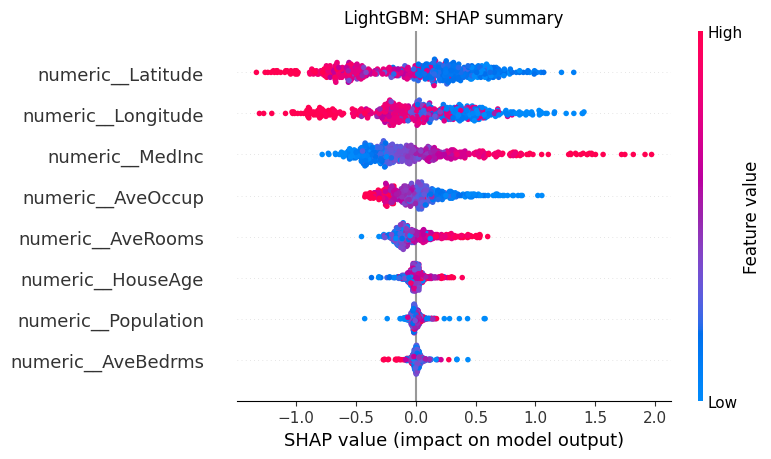

In [92]:
best_model_name = comparison_df.loc[0, 'model']
best_pipeline = tuned_pipelines[best_model_name]
best_preprocessor = best_pipeline.named_steps['preprocess']
best_regressor = best_pipeline.named_steps['regressor']

X_sample = X_train_full.sample(n=min(500, X_train_full.shape[0]), random_state=RANDOM_STATE)
X_sample_processed = best_preprocessor.transform(X_sample)
feature_names = best_preprocessor.get_feature_names_out()

explainer = shap.Explainer(best_regressor)
shap_values = explainer(X_sample_processed)

shap.summary_plot(shap_values, feature_names=feature_names, show=False)
plt.title(f'{best_model_name}: SHAP summary', fontsize=12)
plt.tight_layout()
plt.show()



### Interpreting feature importance vs interpretability tools
- **Built-in feature importance** (gain, split count, impurity) is fast but purely model-specific and global. It explains how often a feature was used during training, not how a single prediction was made.
- **Permutation importance** measures the drop in performance when a feature is shuffled. It is model-agnostic and reflects impact on the metric you care about, but it is still a global view.
- **Partial dependence (PDP) & Individual Conditional Expectation (ICE)** explore how predictions change as you vary one or two features. They help communicate marginal trends but assume feature independence.
- **Accumulated Local Effects (ALE)** offer a PDP alternative that is more robust when features are correlated.
- **SHAP values** deliver consistent, local attributions by decomposing each prediction into feature contributions. Aggregate plots (summary, dependence) provide a bridge between local and global explanations.
- **LIME** or **Anchors** can complement SHAP when you need sparse, human-readable explanations for individual instances.

Pair global importance (for example, permutation scores) with local explanations (for example, SHAP) to build a trustworthy story around gradient-boosted models and random forests.
